# Conditional GAN (cGAN) — Cat & Dog Image Generation

**Project:** Build a Conditional Generative Adversarial Network to generate images of cats or dogs, conditioned on class labels.

| Detail | Value |
|---|---|
| Dataset | Cats vs Dogs (TensorFlow Datasets) |
| Label 0 | Cat 🐱 |
| Label 1 | Dog 🐶 |
| Output Resolution | 64 × 64 × 3 |
| Hardware Target | Apple Mac Mini M4 16 GB (Metal GPU) |

---

## Part 0 — Environment & Hardware Check

> `TF_CPP_MIN_LOG_LEVEL` **must** be set before TensorFlow is imported — the C++ runtime reads it at process start.

In [1]:
import os

# ⚠️  Must precede ALL tensorflow imports
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # 0=all, 1=info, 2=warn, 3=error

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds

# ── Global reproducibility seed ───────────────────────────────────────────────
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow          : {tf.__version__}")
print(f"TF Datasets         : {tfds.__version__}")
print(f"NumPy               : {np.__version__}")

gpus = tf.config.list_physical_devices("GPU")
cpus = tf.config.list_physical_devices("CPU")
print(f"\nCPU devices         : {len(cpus)}")
print(f"GPU / Metal devices : {len(gpus)}")
for g in gpus:
    print(f"  → {g.name}")

if gpus:
    print("\n✅ Apple Metal GPU acceleration is ACTIVE")
else:
    print("\n⚠️  No Metal GPU — falling back to CPU")

TensorFlow          : 2.15.0
TF Datasets         : 4.9.9
NumPy               : 1.26.4

CPU devices         : 1
GPU / Metal devices : 1
  → /physical_device:GPU:0

✅ Apple Metal GPU acceleration is ACTIVE


---
## Part 1 — Data Preparation
### 1.1 — Load Dataset

In [2]:
(ds_train, ds_test), ds_info = tfds.load(
    "cats_vs_dogs",
    split=["train[:90%]", "train[90%:]"],
    shuffle_files=True,
    as_supervised=True,
    with_info=True
)

LABEL_NAMES = ds_info.features["label"].names    # ("cat", "dog")
NUM_CLASSES = ds_info.features["label"].num_classes  # 2

print("Dataset loaded!")
print(f"  Training samples : {ds_train.cardinality().numpy()}")
print(f"  Testing  samples : {ds_test.cardinality().numpy()}")
print(f"  Classes          : {list(LABEL_NAMES)}  (0=cat, 1=dog)")

Dataset loaded!
  Training samples : 20936
  Testing  samples : 2326
  Classes          : ['cat', 'dog']  (0=cat, 1=dog)


### 1.2 — Visualize Raw Samples

/var/folders/xb/h9lj1q7n4094ljx17mfmchq80000gn/T/ipykernel_4606/1468343511.py:13: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/ramsundar/Documents/IITM-Graded-Projects/Week 37/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


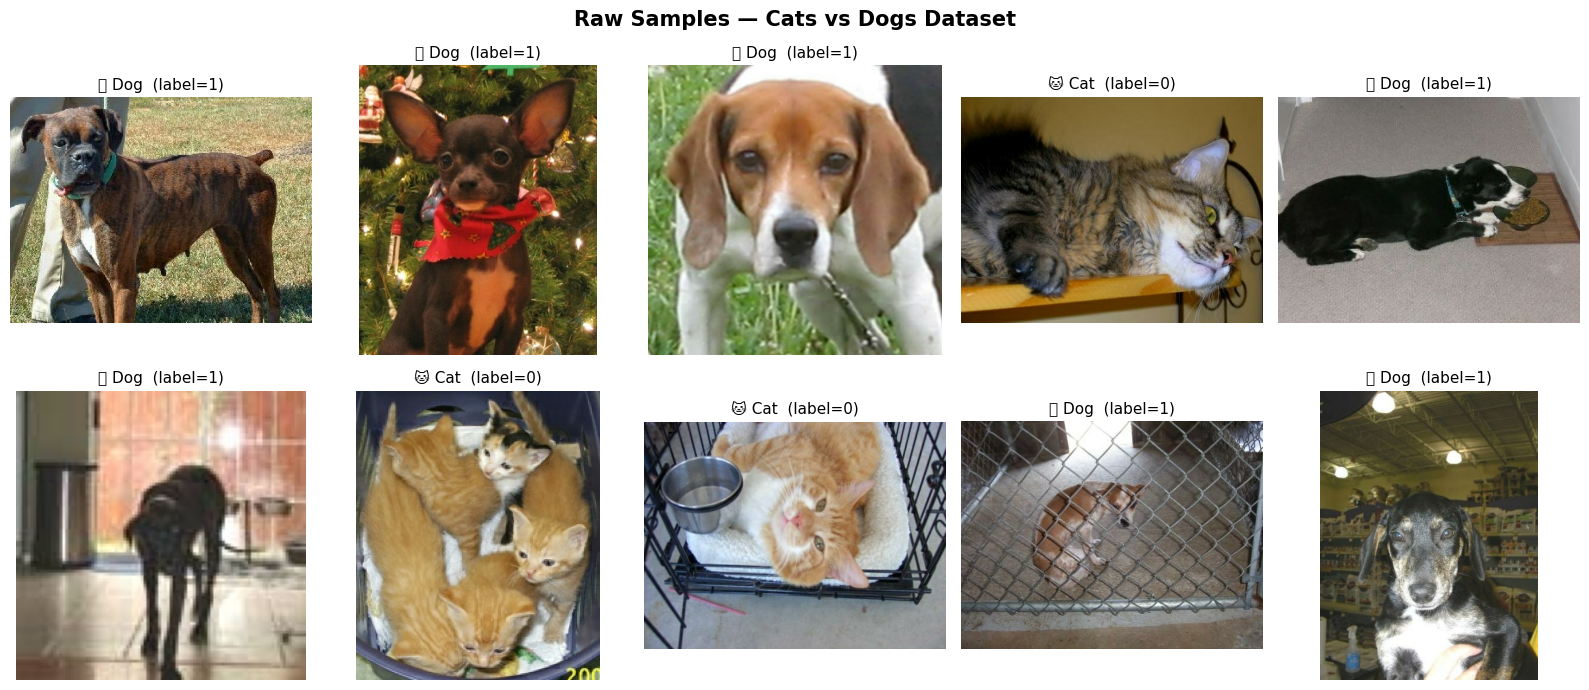

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle("Raw Samples — Cats vs Dogs Dataset", fontsize=15, fontweight="bold")

for i, (image, label) in enumerate(ds_train.take(10)):
    row, col = divmod(i, 5)
    ax = axes[row][col]
    ax.imshow(image.numpy())
    name  = LABEL_NAMES[int(label.numpy())]
    emoji = "🐱" if name == "cat" else "🐶"
    ax.set_title(f"{emoji} {name.capitalize()}  (label={label.numpy()})", fontsize=11)
    ax.axis("off")

plt.tight_layout()
plt.show()
plt.close()

### 1.3 — Hyperparameters
All tuneable knobs in one place — change here and re-run.

In [4]:
IMAGE_SIZE   = 64      # Spatial resolution
BATCH_SIZE   = 128     # M4 16 GB unified RAM — 128 doubles GPU utilisation vs 64
                       # with negligible extra memory for 64×64×3 images
NOISE_DIM    = 128     # Latent z dimension
EMBED_DIM    = 50      # Label embedding dimension (2 classes → small table is fine)
BUFFER_SIZE  = 10_000  # Shuffle buffer size
EPOCHS       = 100      # ≥ 10 as required
LR           = 2e-4    # Adam learning rate — standard DCGAN value
BETA_1       = 0.5     # Adam β₁ — recommended for GAN training stability
BETA_2       = 0.999   # Adam β₂ — standard
CLIP_NORM    = 1.0     # Gradient clipping norm — prevents early exploding gradients
LABEL_SMOOTH = 0.1     # One-sided label smoothing (real targets = 1 − ε = 0.9)

print("Hyperparameters registered ✅")
print(f"  BATCH_SIZE={BATCH_SIZE}  NOISE_DIM={NOISE_DIM}  EMBED_DIM={EMBED_DIM}")
print(f"  LR={LR}  BETA_1={BETA_1}  CLIP_NORM={CLIP_NORM}  LABEL_SMOOTH={LABEL_SMOOTH}")

Hyperparameters registered ✅
  BATCH_SIZE=128  NOISE_DIM=128  EMBED_DIM=50
  LR=0.0002  BETA_1=0.5  CLIP_NORM=1.0  LABEL_SMOOTH=0.1


### 1.4 — Preprocessing & Batching

**Key decisions:**
- `tf.cast` to `float32` **before** `resize` — avoids uint8 bilinear interpolation artifacts  
- **Resize-then-center-crop** (not squash) — the dataset has mixed aspect ratios; squashing distorts subjects  
- **Horizontal flip augmentation** — simple, label-preserving, effectively doubles diversity and prevents D from memorising orientation  
- `.cache()` after `.map()` — stores preprocessed images in RAM after epoch 1; M4's 16 GB holds ~21k×64×64×3 float32 (≈ 1 GB) easily, eliminating per-epoch disk I/O  
- `drop_remainder=True` — static batch shape required for `input_signature` in `@tf.function`

In [5]:
def preprocess_train(image, label):
    """
    Training pipeline:
      1. Cast uint8 → float32 before resize (avoids interpolation artifacts)
      2. Resize shortest side to IMAGE_SIZE, then center-crop to IMAGE_SIZE×IMAGE_SIZE
         This preserves aspect ratio instead of squashing subjects
      3. Random horizontal flip — label-preserving augmentation
      4. Normalize [0, 255] → [-1, 1]  (matches generator tanh output)
    """
    image = tf.cast(image, tf.float32)
    # Resize shortest edge to IMAGE_SIZE keeping aspect ratio, then crop center
    image = tf.image.resize_with_crop_or_pad(image, IMAGE_SIZE, IMAGE_SIZE)
    # Random horizontal flip — cats and dogs look the same mirrored
    image = tf.image.random_flip_left_right(image)
    image = (image / 127.5) - 1.0
    label = tf.cast(label, tf.int32)
    return image, label

def preprocess_eval(image, label):
    """Eval pipeline: no flip, deterministic crop."""
    image = tf.cast(image, tf.float32)
    image = tf.image.resize_with_crop_or_pad(image, IMAGE_SIZE, IMAGE_SIZE)
    image = (image / 127.5) - 1.0
    label = tf.cast(label, tf.int32)
    return image, label

train_dataset = (
    ds_train
    .map(preprocess_train, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()                                        # ← store in RAM after epoch 1
    .shuffle(BUFFER_SIZE, seed=SEED)
    .batch(BATCH_SIZE, drop_remainder=True)         # static shape → faster graph
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    ds_test
    .map(preprocess_eval, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE, drop_remainder=False)
    .prefetch(tf.data.AUTOTUNE)
)

# Verify one batch
for sample_images, sample_labels in train_dataset.take(1):
    print("Preprocessing verified!")
    print(f"  Image batch shape : {sample_images.shape}")
    print(f"  Label batch shape : {sample_labels.shape}")
    print(f"  Pixel range       : [{sample_images.numpy().min():.3f},  {sample_images.numpy().max():.3f}]")
    print(f"  Unique labels     : {np.unique(sample_labels.numpy())}")

Preprocessing verified!
  Image batch shape : (128, 64, 64, 3)
  Label batch shape : (128,)
  Pixel range       : [-1.000,  1.000]
  Unique labels     : [0 1]


---
## Part 2 — Architecture

### 2.1 — Generator

**Design decisions:**
- Label embedded to `EMBED_DIM=50`, **concatenated** with noise (Mirza & Osindero, 2014) — gives the Dense layer independent access to both signals; element-wise multiply risks zero-ing gradients when embeddings initialise near 0  
- `Dense → LeakyReLU → Reshape → BN` order — BN operates on the spatial feature map `(4,4,512)`, not the flat `(8192,)` vector; spatial statistics are far more meaningful for image generation  
- Four `Conv2DTranspose` blocks with `BatchNorm` + `LeakyReLU`: `4→8→16→32→64`  
- **Final layer: `Conv2D` (not `Conv2DTranspose`)** — transposed conv at the output causes checkerboard artifacts due to uneven overlap; a plain conv after the last upsample is cleaner  
- `use_bias=False` inside BN blocks — BN's β parameter absorbs the bias term exactly

In [6]:
def build_generator(noise_dim=NOISE_DIM, num_classes=NUM_CLASSES, embed_dim=EMBED_DIM):
    """cGAN Generator: (noise[noise_dim], label[1]) → image[64, 64, 3] ∈ [-1, 1]."""

    noise_input = tf.keras.Input(shape=(noise_dim,), name="noise_input")
    label_input = tf.keras.Input(shape=(1,),         name="label_input")

    # ── Label embedding — concat (not multiply) with noise ────────────────────
    label_emb = tf.keras.layers.Embedding(
        input_dim=num_classes, output_dim=embed_dim, name="g_label_emb"
    )(label_input)
    label_emb = tf.keras.layers.Flatten(name="g_label_flat")(label_emb)

    x = tf.keras.layers.Concatenate(name="g_concat")([noise_input, label_emb])
    # x shape: (noise_dim + embed_dim,) = (178,)

    # ── Project to 4×4×512, apply activation THEN reshape THEN BN ────────────
    # BN is placed AFTER Reshape so it normalises (4,4,512) spatial maps,
    # not the flat (8192,) vector — spatial statistics are far more stable.
    x = tf.keras.layers.Dense(4 * 4 * 512, use_bias=False, name="g_dense")(x)
    x = tf.keras.layers.LeakyReLU(0.2, name="g_lrelu_dense")(x)
    x = tf.keras.layers.Reshape((4, 4, 512), name="g_reshape")(x)
    x = tf.keras.layers.BatchNormalization(name="g_bn_dense")(x)   # BN on spatial map

    # ── Up-sampling blocks 4→8→16→32→64 ─────────────────────────────────────
    for filters, tag in [(256, "1"), (128, "2"), (64, "3"), (32, "4")]:
        x = tf.keras.layers.Conv2DTranspose(
            filters, kernel_size=4, strides=2, padding="same",
            use_bias=False, name=f"g_convT{tag}"
        )(x)
        x = tf.keras.layers.BatchNormalization(name=f"g_bn{tag}")(x)
        x = tf.keras.layers.LeakyReLU(0.2, name=f"g_lrelu{tag}")(x)

    # ── Output: Conv2D avoids checkerboard artifacts from ConvTranspose ───────
    output = tf.keras.layers.Conv2D(
        3, kernel_size=3, strides=1, padding="same",
        activation="tanh", use_bias=True, name="g_output"
    )(x)
    # output shape: (64, 64, 3)  pixel range [-1, 1]

    return tf.keras.Model(
        inputs=[noise_input, label_input], outputs=output, name="Generator"
    )

generator = build_generator()
generator.summary(line_length=80)

Model: "Generator"
________________________________________________________________________________
 Layer (type)           Output Shape            Param   Connected to            
                                                 #                              
 label_input (InputLay  [(None, 1)]             0       []                      
 er)                                                                            
                                                                                
 g_label_emb (Embeddin  (None, 1, 50)           100     ['label_input[0][0]']   
 g)                                                                             
                                                                                
 noise_input (InputLay  [(None, 128)]           0       []                      
 er)                                                                            
                                                                                
 g_label_

In [7]:
_noise  = tf.random.normal([4, NOISE_DIM])
_labels = tf.constant([[0], [1], [0], [1]], dtype=tf.int32)
_out    = generator([_noise, _labels], training=False)

assert _out.shape == (4, 64, 64, 3), f"Unexpected shape: {_out.shape}"
print(f"Generator output shape : {_out.shape}   ✅")
print(f"Pixel range            : [{_out.numpy().min():.4f}, {_out.numpy().max():.4f}]")
del _noise, _labels, _out

Generator output shape : (4, 64, 64, 3)   ✅
Pixel range            : [-0.0164, 0.0211]


### 2.2 — Discriminator

**Design decisions:**
- Label embedded → small Dense projection → `(64, 64, 1)` spatial map, concatenated channel-wise → `(64, 64, 4)` input  
- **No `BatchNormalization`** — BN in D destabilises GAN training (DCGAN paper)  
- **`use_bias=True`** — without BN the bias term is load-bearing for non-zero mean activations  
- **Dropout only in deeper blocks (128, 256, 512)**, not block 1 — Dropout at the input-adjacent layer discards too much early spatial detail  
- Raw logit output (no sigmoid) — loss uses `from_logits=True` for numerical stability

In [8]:
def build_discriminator(image_size=IMAGE_SIZE, num_classes=NUM_CLASSES, embed_dim=EMBED_DIM):
    """
    cGAN Discriminator: (image[64,64,3], label[1]) → raw logit scalar.
    No sigmoid — BCE loss uses from_logits=True (numerically stable).
    """

    image_input = tf.keras.Input(shape=(image_size, image_size, 3), name="image_input")
    label_input = tf.keras.Input(shape=(1,),                        name="label_input")

    # ── Label → spatial map (image_size, image_size, 1) ──────────────────────
    # Small embedding table (embed_dim=50) + Dense projection keeps param count low
    label_emb = tf.keras.layers.Embedding(
        input_dim=num_classes, output_dim=embed_dim, name="d_label_emb"
    )(label_input)
    label_emb = tf.keras.layers.Flatten(name="d_label_flat")(label_emb)
    label_emb = tf.keras.layers.Dense(
        image_size * image_size, use_bias=True, name="d_label_proj"
    )(label_emb)
    label_emb = tf.keras.layers.Reshape(
        (image_size, image_size, 1), name="d_label_spatial"
    )(label_emb)

    # ── Concat image (3ch) + label map (1ch) → (64, 64, 4) ───────────────────
    x = tf.keras.layers.Concatenate(axis=-1, name="d_concat")([image_input, label_emb])

    # ── Block 1 — 64→32, NO Dropout: preserve early spatial detail ───────────
    x = tf.keras.layers.Conv2D(
        64, kernel_size=4, strides=2, padding="same",
        use_bias=True, name="d_conv1"
    )(x)
    x = tf.keras.layers.LeakyReLU(0.2, name="d_lrelu1")(x)
    # No Dropout here — first block is input-adjacent; early features are fragile

    # ── Blocks 2-4 — 32→16→8→4, Dropout on deeper layers only ───────────────
    for filters, tag in [(128, "2"), (256, "3"), (512, "4")]:
        x = tf.keras.layers.Conv2D(
            filters, kernel_size=4, strides=2, padding="same",
            use_bias=True, name=f"d_conv{tag}"
        )(x)
        x = tf.keras.layers.LeakyReLU(0.2, name=f"d_lrelu{tag}")(x)
        x = tf.keras.layers.Dropout(0.3, name=f"d_drop{tag}")(x)

    # ── Classifier head — raw logit (no sigmoid) ──────────────────────────────
    x      = tf.keras.layers.Flatten(name="d_flatten")(x)
    output = tf.keras.layers.Dense(1, name="d_logit")(x)

    return tf.keras.Model(
        inputs=[image_input, label_input], outputs=output, name="Discriminator"
    )

discriminator = build_discriminator()
discriminator.summary(line_length=80)

Model: "Discriminator"
________________________________________________________________________________
 Layer (type)           Output Shape            Param   Connected to            
                                                 #                              
 label_input (InputLay  [(None, 1)]             0       []                      
 er)                                                                            
                                                                                
 d_label_emb (Embeddin  (None, 1, 50)           100     ['label_input[0][0]']   
 g)                                                                             
                                                                                
 d_label_flat (Flatten  (None, 50)              0       ['d_label_emb[0][0]']   
 )                                                                              
                                                                                
 d_la

In [9]:
_imgs = tf.random.normal([4, IMAGE_SIZE, IMAGE_SIZE, 3])
_lbls = tf.constant([[0], [1], [0], [1]], dtype=tf.int32)
_dout = discriminator([_imgs, _lbls], training=False)

assert _dout.shape == (4, 1), f"Unexpected shape: {_dout.shape}"
print(f"Discriminator output shape : {_dout.shape}   ✅  (raw logits)")
print(f"Logit values               : {_dout.numpy().flatten().round(4)}")
del _imgs, _lbls, _dout

Discriminator output shape : (4, 1)   ✅  (raw logits)
Logit values               : [-0.0217  0.0331 -0.0106 -0.0477]


---
## Part 3 — Loss Functions & Optimizers

| Component | Choice | Reason |
|---|---|---|
| Loss | `BinaryCrossentropy(from_logits=True)` | Log-sum-exp trick — stable near 0 and 1 |
| G loss | `BCE(fake_logits, 1.0)` | G wants D to classify fakes as real |
| D real loss | `BCE(real_logits, 1−ε)` | One-sided smoothing prevents D over-confidence |
| D fake loss | `BCE(fake_logits, 0.0)` | D wants to correctly reject fakes |
| Optimizer | Adam · lr=2e-4 · β₁=0.5 | Standard DCGAN setting |
| Gradient clip | `clipnorm=1.0` | Guards against early gradient explosions |

In [10]:
# from_logits=True: TF fuses sigmoid + cross-entropy via log-sum-exp → stable
bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def generator_loss(fake_logits):
    """
    G wants D to output high logits for generated images ("fool" D).
    No label smoothing on G side — G needs a clean gradient signal.
    """
    return bce(tf.ones_like(fake_logits), fake_logits)

def discriminator_loss(real_logits, fake_logits):
    """
    One-sided label smoothing on real targets only (Goodfellow et al. recommended):
      real  →  target = 1 - LABEL_SMOOTH = 0.9   (soft real)
      fake  →  target = 0.0                       (hard fake — do not smooth fake side)
    Smoothing fake targets towards 0.1 would give G misleading gradient information.
    
    LABEL_SMOOTH is read at call time from module scope — not baked into default arg
    to avoid Python's early-binding gotcha with mutable globals.
    """
    real_targets = tf.ones_like(real_logits) * (1.0 - LABEL_SMOOTH)
    real_loss    = bce(real_targets,               real_logits)
    fake_loss    = bce(tf.zeros_like(fake_logits), fake_logits)
    return real_loss + fake_loss

# ── Optimizers — gradient clipping guards against early instability ───────────
gen_optimizer  = tf.keras.optimizers.Adam(
    learning_rate=LR, beta_1=BETA_1, beta_2=BETA_2, clipnorm=CLIP_NORM
)
disc_optimizer = tf.keras.optimizers.Adam(
    learning_rate=LR, beta_1=BETA_1, beta_2=BETA_2, clipnorm=CLIP_NORM
)

print(f"Loss            : BinaryCrossentropy(from_logits=True)")
print(f"Label smoothing : {LABEL_SMOOTH}  (real targets = {1.0 - LABEL_SMOOTH})")
print(f"Gradient clip   : clipnorm={CLIP_NORM}")
print(f"Gen  optimizer  : Adam | lr={LR} | β₁={BETA_1} | β₂={BETA_2}")
print(f"Disc optimizer  : Adam | lr={LR} | β₁={BETA_1} | β₂={BETA_2}")

Loss            : BinaryCrossentropy(from_logits=True)
Label smoothing : 0.1  (real targets = 0.9)
Gradient clip   : clipnorm=1.0
Gen  optimizer  : Adam | lr=0.0002 | β₁=0.5 | β₂=0.999
Disc optimizer  : Adam | lr=0.0002 | β₁=0.5 | β₂=0.999


---
## Part 4 — Training

### 4.1 — Training Step

**Critical design — single `persistent=True` tape with one G forward pass:**

The previous pattern of running G inside `disc_tape` and then again inside a separate `gen_tape` with 
 does **not** actually produce the same samples — inside `@tf.function`, `tf.random.normal` is an op that re-executes each time the op node is reached in the graph. Two separate tape contexts → two different noise realisations → D and G updates are computed from different fake image batches.

**Fix:** Use a single `persistent=True` tape covering the full forward pass. Generate `fake_images` **once**. Compute D's loss and G's loss from that same batch. Apply gradients separately to D's and G's variables. Delete the tape explicitly (`del tape`) to release memory.

In [11]:
@tf.function(input_signature=[
    tf.TensorSpec(shape=(BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, 3), dtype=tf.float32),
    tf.TensorSpec(shape=(BATCH_SIZE,),                           dtype=tf.int32)
])
def train_step(real_images, real_labels):
    """
    One optimiser update for both G and D.

    Uses a SINGLE persistent GradientTape:
      - fake_images is generated ONCE → D and G losses are computed from the
        same fake batch, keeping the training signal consistent.
      - persistent=True allows .gradient() to be called twice on the same tape.
      - The tape is explicitly deleted after both gradient computations to
        release the intermediate tensors held in memory.

    D is called with training=True for its OWN update (Dropout active, tracking stats).
    D is called with training=False during G's loss (Dropout OFF — G sees D at
    full capacity, giving the strongest gradient signal for G to improve against).
    """
    noise       = tf.random.normal([BATCH_SIZE, NOISE_DIM])
    fake_labels = tf.random.uniform(
        shape=(BATCH_SIZE, 1), minval=0, maxval=NUM_CLASSES, dtype=tf.int32
    )
    real_labels_2d = tf.reshape(real_labels, (BATCH_SIZE, 1))

    with tf.GradientTape(persistent=True) as tape:
        # ── Single G forward pass — both losses computed from this batch ──────
        fake_images = generator([noise, fake_labels], training=True)

        # D forward pass: training=True → Dropout active, BN uses batch stats
        real_logits = discriminator([real_images, real_labels_2d], training=True)
        fake_logits = discriminator([fake_images, fake_labels],    training=True)
        d_loss      = discriminator_loss(real_logits, fake_logits)

        # G loss: D called with training=False → Dropout OFF, D at full strength
        # This gives G the hardest possible gradient signal to improve against
        fake_logits_for_g = discriminator([fake_images, fake_labels], training=False)
        g_loss            = generator_loss(fake_logits_for_g)

    # ── Apply gradients — tape is used twice, then explicitly freed ───────────
    disc_grads = tape.gradient(d_loss, discriminator.trainable_variables)
    gen_grads  = tape.gradient(g_loss, generator.trainable_variables)
    del tape   # release persistent tape memory immediately

    disc_optimizer.apply_gradients(zip(disc_grads, discriminator.trainable_variables))
    gen_optimizer.apply_gradients(zip(gen_grads,   generator.trainable_variables))

    return g_loss, d_loss

print("train_step compiled with @tf.function + persistent tape ✅")

train_step compiled with @tf.function + persistent tape ✅


### 4.2 — Visualization Helper

/var/folders/xb/h9lj1q7n4094ljx17mfmchq80000gn/T/ipykernel_4606/3396138272.py:35: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


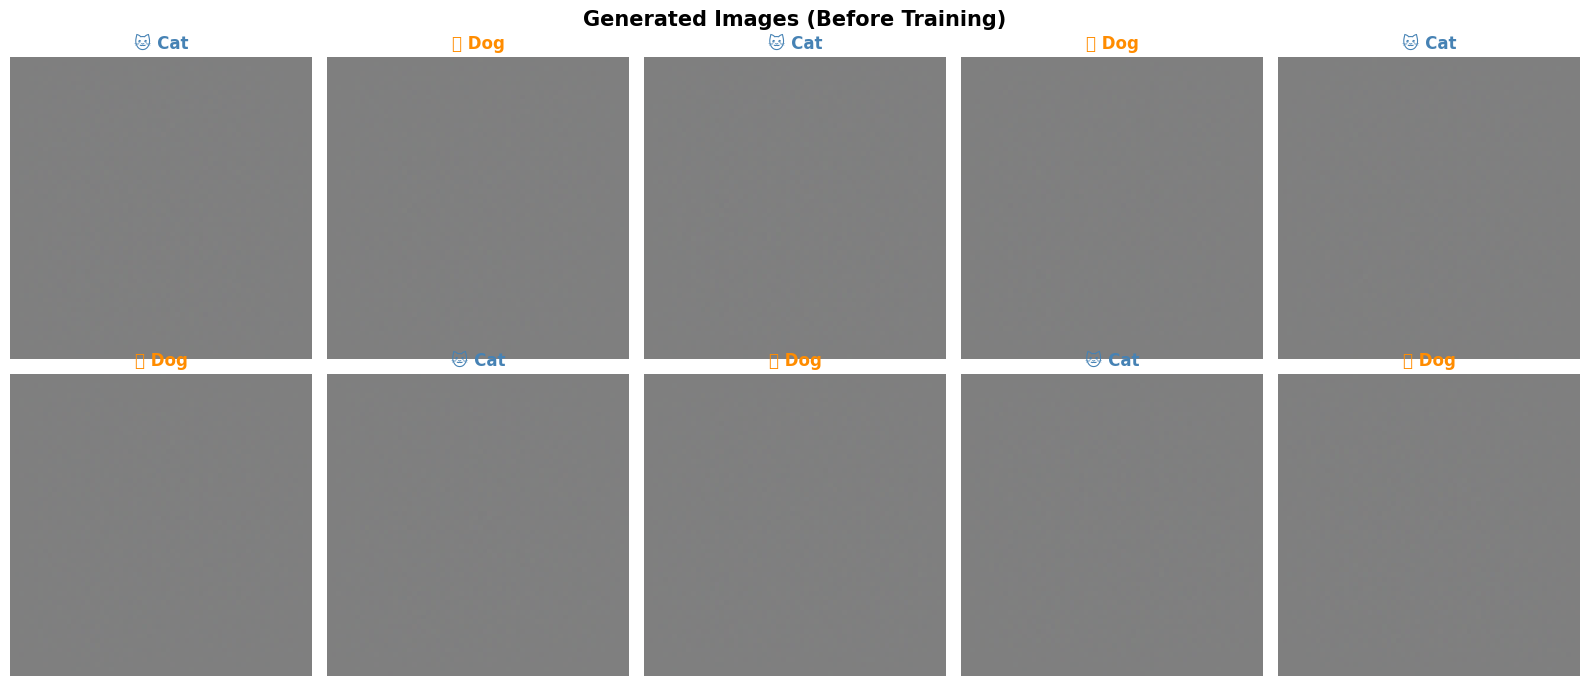

In [12]:
NUM_VIZ      = 10
# stateless_normal: fully reproducible regardless of global graph state
fixed_noise  = tf.random.stateless_normal([NUM_VIZ, NOISE_DIM], seed=(SEED, 0))
fixed_labels = tf.constant(
    [[i % NUM_CLASSES] for i in range(NUM_VIZ)], dtype=tf.int32
)   # alternating: cat, dog, cat, dog …

os.makedirs("cgan_outputs", exist_ok=True)

def denormalize(images):
    """Model output [-1, 1] → display-ready [0, 1] float32 NumPy array."""
    return np.clip((np.asarray(images) + 1.0) / 2.0, 0.0, 1.0)

def generate_and_show(epoch=None, save=False):
    """Generate from fixed seed inputs, denormalize, render 2×5 grid."""
    images = denormalize(generator([fixed_noise, fixed_labels], training=False))

    fig, axes = plt.subplots(2, 5, figsize=(16, 7))
    title = (
        f"Generated Images — Epoch {epoch:>2}"
        if epoch is not None
        else "Generated Images (Before Training)"
    )
    fig.suptitle(title, fontsize=15, fontweight="bold")

    for i, ax in enumerate(axes.flatten()):
        ax.imshow(images[i])
        name  = LABEL_NAMES[int(fixed_labels[i][0].numpy())]
        emoji = "🐱" if name == "cat" else "🐶"
        color = "steelblue" if name == "cat" else "darkorange"
        ax.set_title(f"{emoji} {name.capitalize()}", fontsize=12,
                     color=color, fontweight="bold")
        ax.axis("off")

    plt.tight_layout()
    if save and epoch is not None:
        plt.savefig(
            f"cgan_outputs/epoch_{epoch:03d}.png", dpi=80, bbox_inches="tight"
        )
    plt.show()
    plt.close(fig)   # free figure memory — essential inside long training loops

# Baseline: untrained generator output (should look like noise)
generate_and_show(epoch=None, save=False)

### 4.3 — Main Training Loop

`tf.keras.metrics.Mean` objects are created **once outside the loop** and reset per epoch with `.reset_state()` — avoids allocating new TF variables on every epoch.

          cGAN Training — Apple Mac Mini M4 · Metal
  Epochs=100  Batch=128  Noise=128  LR=0.0002
  ClipNorm=1.0  LabelSmooth=0.1
Epoch [ 1/100]  │  Gen Loss: 1.4311  │  Disc Loss: 0.9010
Epoch [ 1/100]  │  Gen Loss: 1.4311  │  Disc Loss: 0.9010
Epoch [ 2/100]  │  Gen Loss: 0.6416  │  Disc Loss: 0.9440
Epoch [ 2/100]  │  Gen Loss: 0.6416  │  Disc Loss: 0.9440
Epoch [ 3/100]  │  Gen Loss: 0.7634  │  Disc Loss: 1.0446
Epoch [ 3/100]  │  Gen Loss: 0.7634  │  Disc Loss: 1.0446
Epoch [ 4/100]  │  Gen Loss: 0.4416  │  Disc Loss: 0.8258
Epoch [ 4/100]  │  Gen Loss: 0.4416  │  Disc Loss: 0.8258
Epoch [ 5/100]  │  Gen Loss: 0.4358  │  Disc Loss: 0.7913
Epoch [ 5/100]  │  Gen Loss: 0.4358  │  Disc Loss: 0.7913


/var/folders/xb/h9lj1q7n4094ljx17mfmchq80000gn/T/ipykernel_4606/3396138272.py:35: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/xb/h9lj1q7n4094ljx17mfmchq80000gn/T/ipykernel_4606/3396138272.py:37: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  plt.savefig(


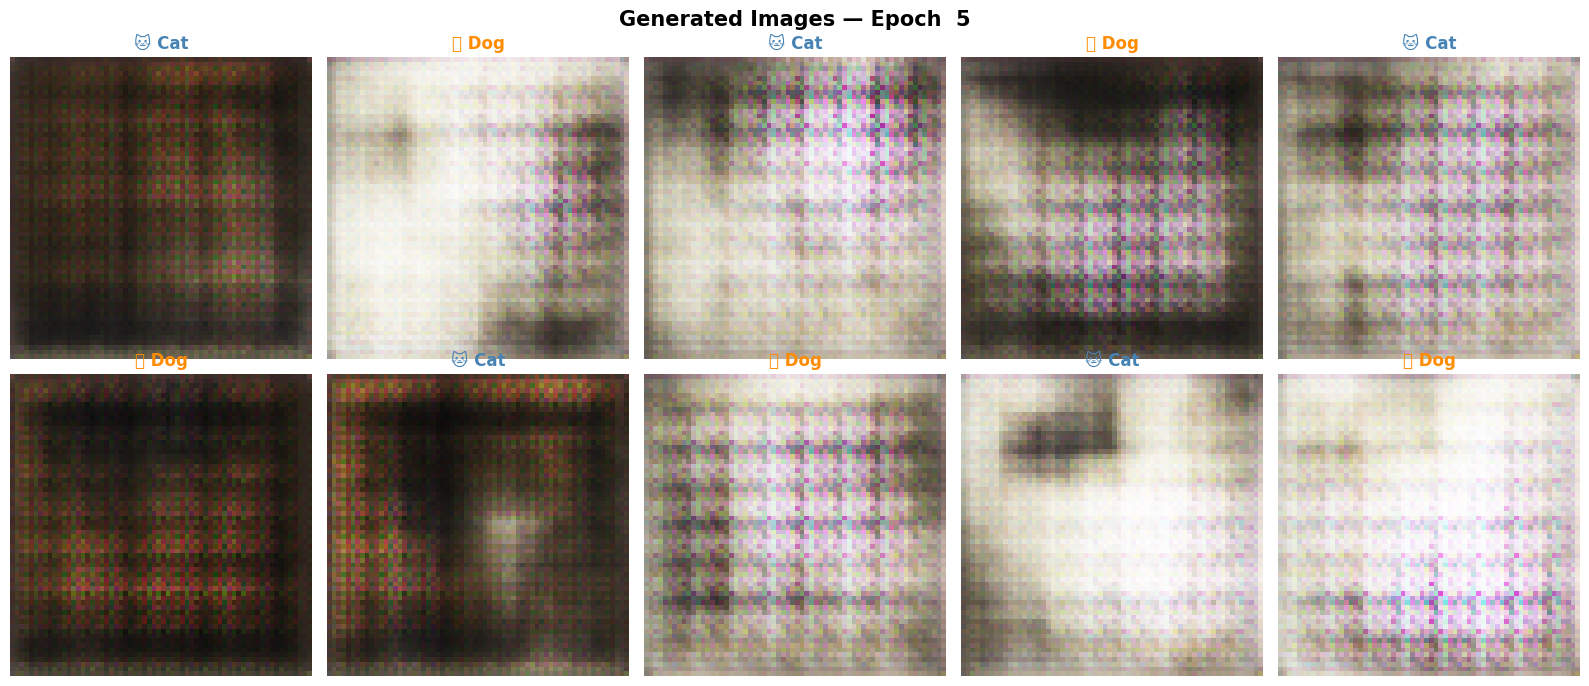

Epoch [ 6/100]  │  Gen Loss: 0.4561  │  Disc Loss: 0.8311
Epoch [ 7/100]  │  Gen Loss: 0.1683  │  Disc Loss: 0.5726
Epoch [ 7/100]  │  Gen Loss: 0.1683  │  Disc Loss: 0.5726
Epoch [ 8/100]  │  Gen Loss: 0.1040  │  Disc Loss: 0.4865
Epoch [ 8/100]  │  Gen Loss: 0.1040  │  Disc Loss: 0.4865
Epoch [ 9/100]  │  Gen Loss: 0.0773  │  Disc Loss: 0.4449
Epoch [ 9/100]  │  Gen Loss: 0.0773  │  Disc Loss: 0.4449
Epoch [10/100]  │  Gen Loss: 0.0672  │  Disc Loss: 0.4186
Epoch [10/100]  │  Gen Loss: 0.0672  │  Disc Loss: 0.4186


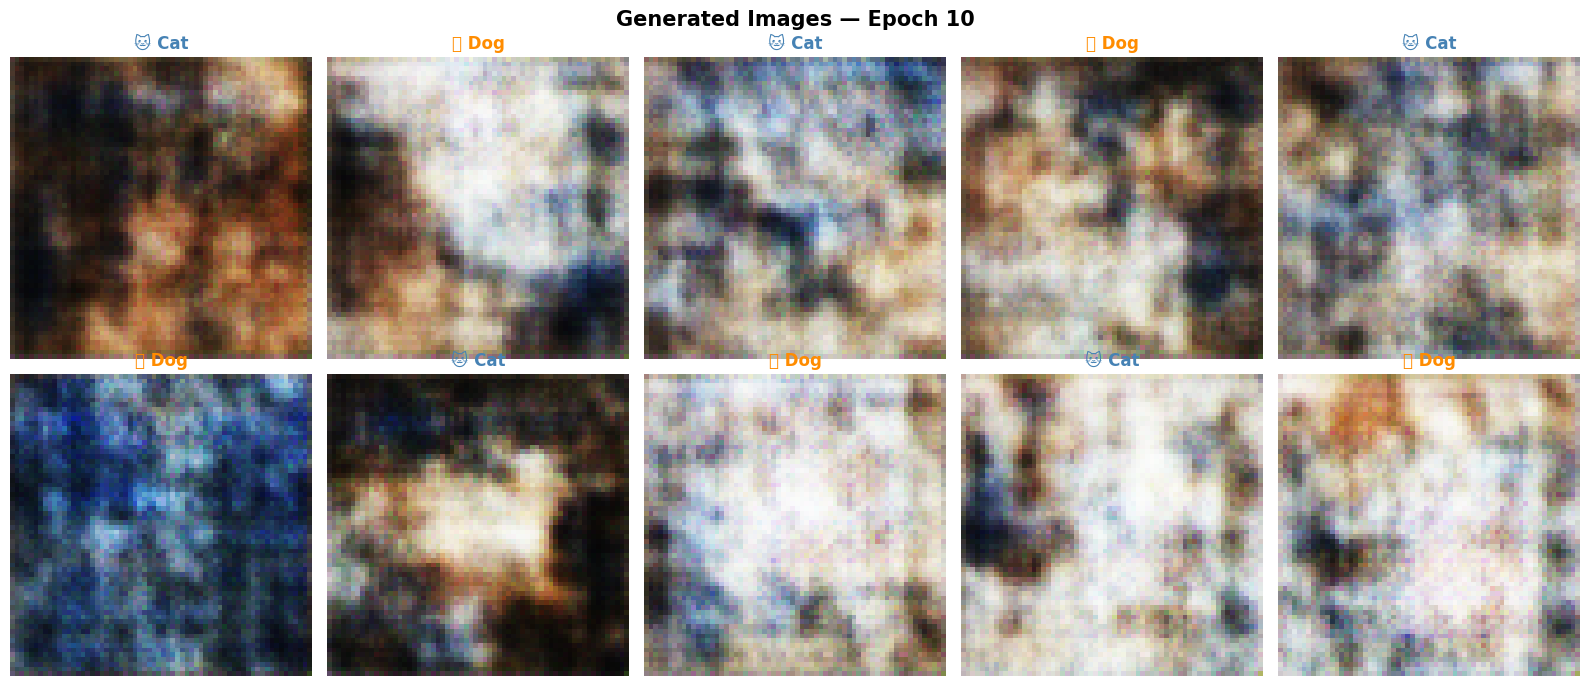

Epoch [11/100]  │  Gen Loss: 0.0630  │  Disc Loss: 0.4046
Epoch [12/100]  │  Gen Loss: 0.0729  │  Disc Loss: 0.4208
Epoch [12/100]  │  Gen Loss: 0.0729  │  Disc Loss: 0.4208
Epoch [13/100]  │  Gen Loss: 0.0575  │  Disc Loss: 0.3919
Epoch [13/100]  │  Gen Loss: 0.0575  │  Disc Loss: 0.3919
Epoch [14/100]  │  Gen Loss: 0.0446  │  Disc Loss: 0.3718
Epoch [14/100]  │  Gen Loss: 0.0446  │  Disc Loss: 0.3718
Epoch [15/100]  │  Gen Loss: 0.0333  │  Disc Loss: 0.3552
Epoch [15/100]  │  Gen Loss: 0.0333  │  Disc Loss: 0.3552


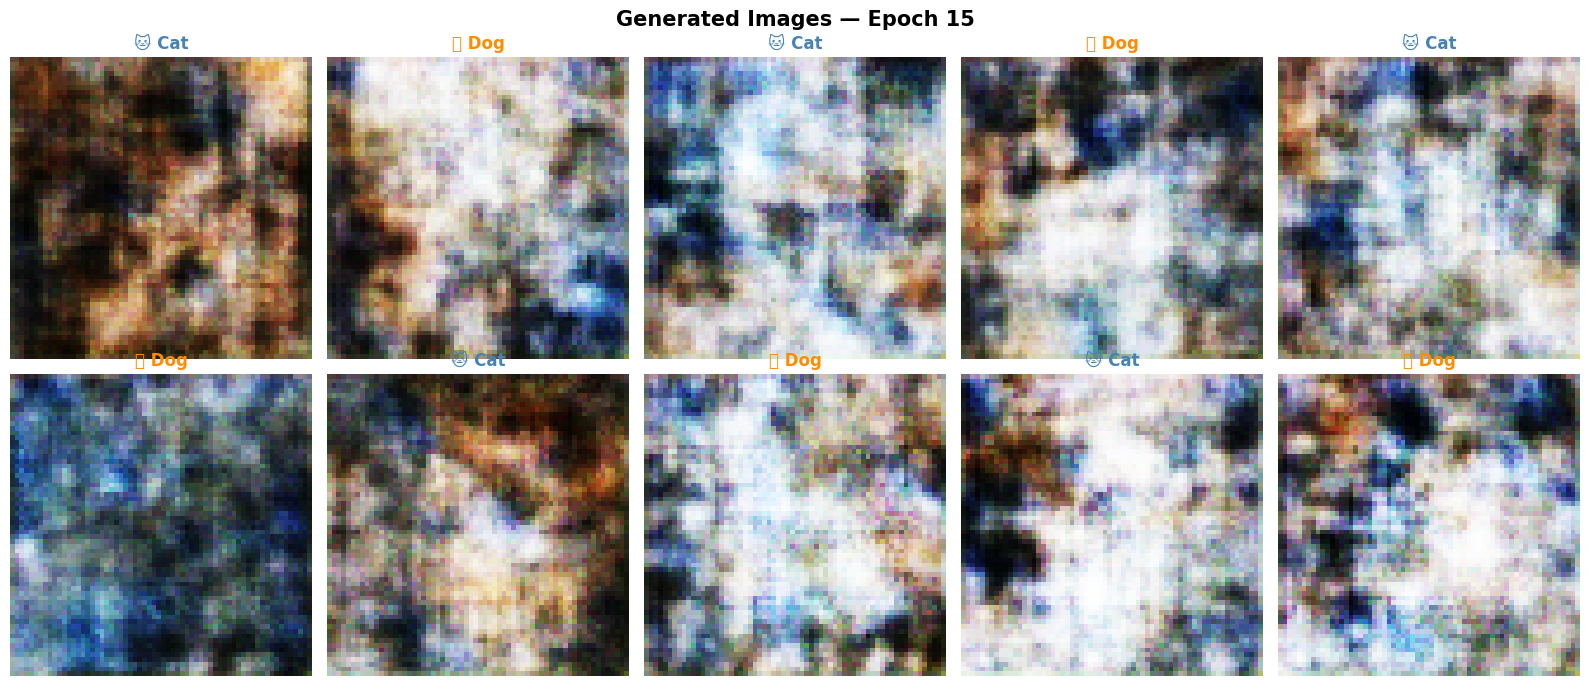

Epoch [16/100]  │  Gen Loss: 0.0326  │  Disc Loss: 0.3563
Epoch [17/100]  │  Gen Loss: 0.0284  │  Disc Loss: 0.3477
Epoch [17/100]  │  Gen Loss: 0.0284  │  Disc Loss: 0.3477
Epoch [18/100]  │  Gen Loss: 0.0245  │  Disc Loss: 0.3452
Epoch [18/100]  │  Gen Loss: 0.0245  │  Disc Loss: 0.3452
Epoch [19/100]  │  Gen Loss: 0.7217  │  Disc Loss: 0.9212
Epoch [19/100]  │  Gen Loss: 0.7217  │  Disc Loss: 0.9212
Epoch [20/100]  │  Gen Loss: 0.4376  │  Disc Loss: 0.7699
Epoch [20/100]  │  Gen Loss: 0.4376  │  Disc Loss: 0.7699


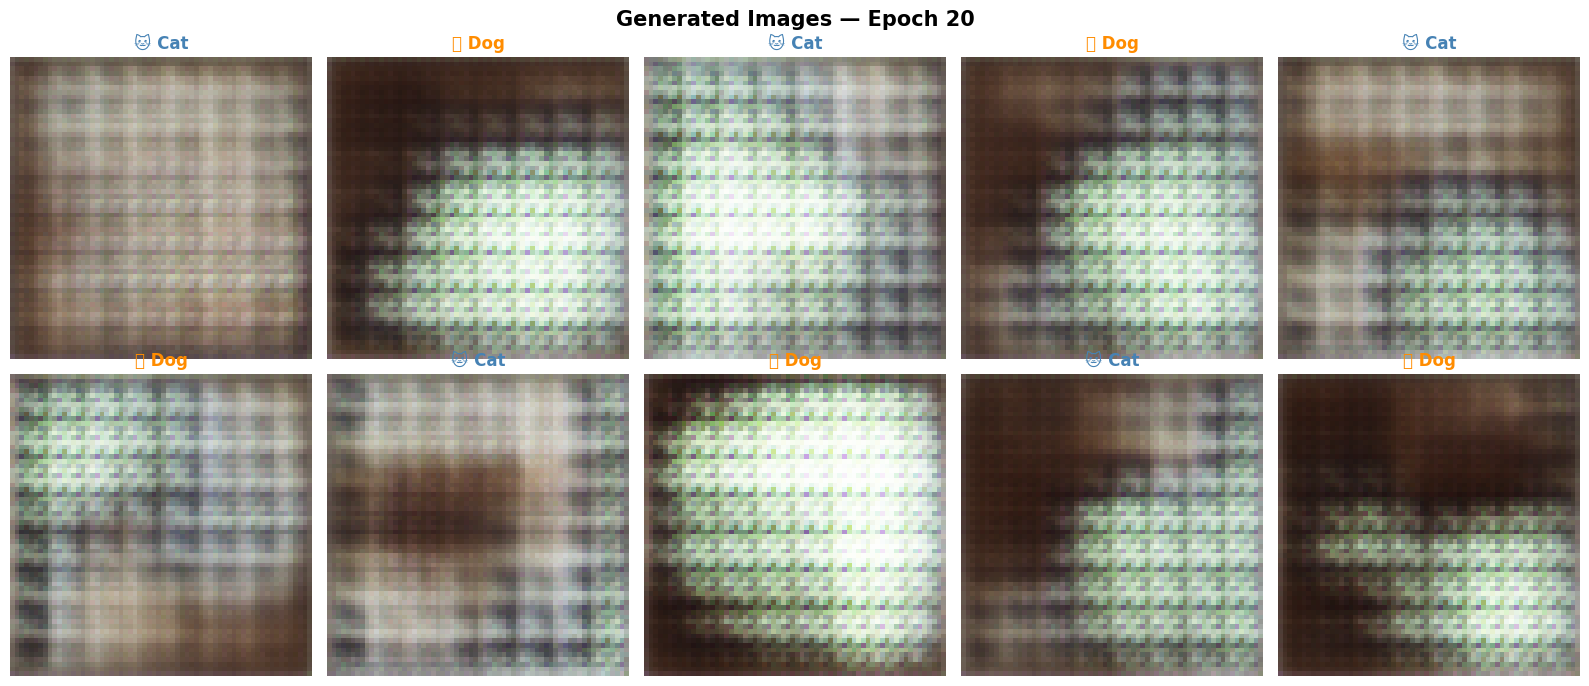

Epoch [21/100]  │  Gen Loss: 0.2677  │  Disc Loss: 0.6344
Epoch [22/100]  │  Gen Loss: 0.2077  │  Disc Loss: 0.5843
Epoch [22/100]  │  Gen Loss: 0.2077  │  Disc Loss: 0.5843
Epoch [23/100]  │  Gen Loss: 0.1248  │  Disc Loss: 0.4847
Epoch [23/100]  │  Gen Loss: 0.1248  │  Disc Loss: 0.4847
Epoch [24/100]  │  Gen Loss: 0.0843  │  Disc Loss: 0.4455
Epoch [24/100]  │  Gen Loss: 0.0843  │  Disc Loss: 0.4455
Epoch [25/100]  │  Gen Loss: 0.0586  │  Disc Loss: 0.4050
Epoch [25/100]  │  Gen Loss: 0.0586  │  Disc Loss: 0.4050


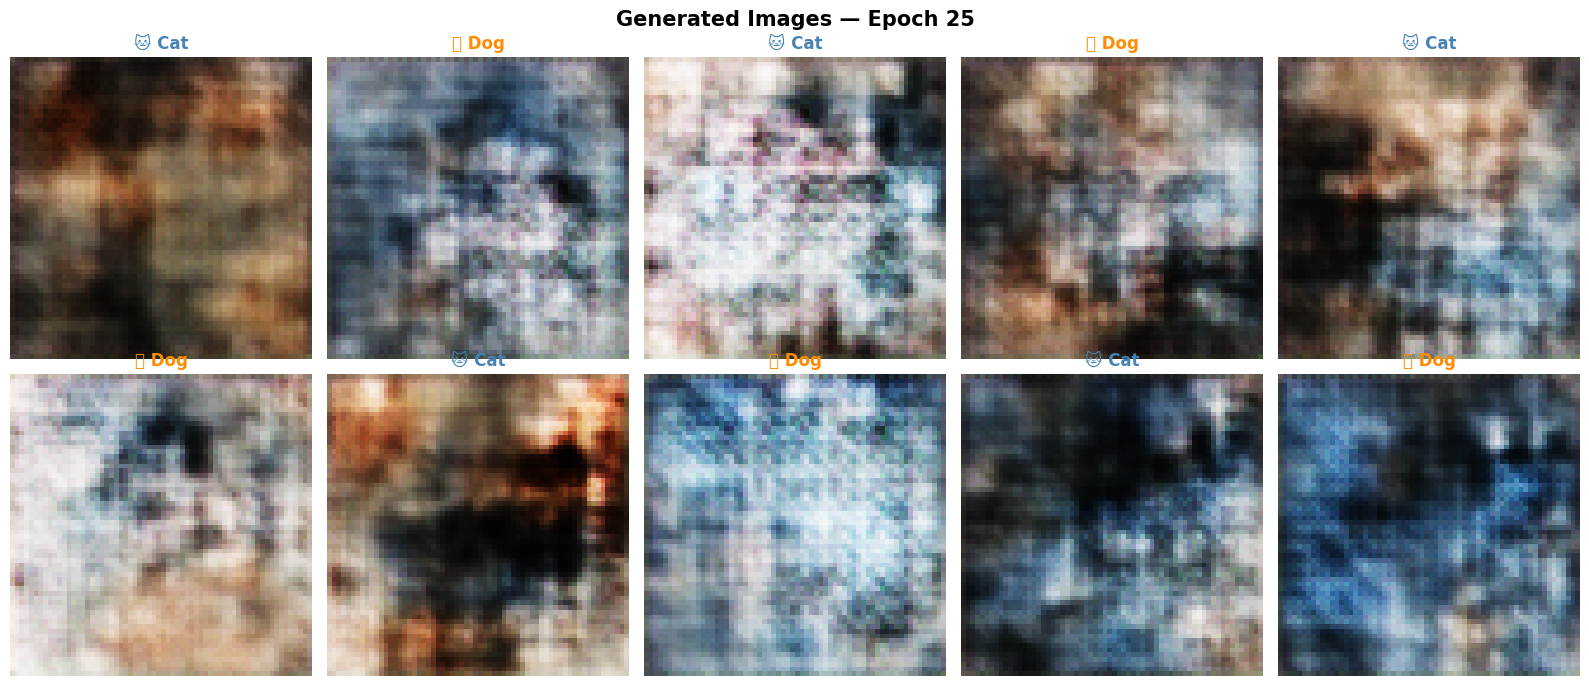

Epoch [26/100]  │  Gen Loss: 0.0413  │  Disc Loss: 0.3758
Epoch [27/100]  │  Gen Loss: 0.0285  │  Disc Loss: 0.3586
Epoch [27/100]  │  Gen Loss: 0.0285  │  Disc Loss: 0.3586
Epoch [28/100]  │  Gen Loss: 0.0179  │  Disc Loss: 0.3452
Epoch [28/100]  │  Gen Loss: 0.0179  │  Disc Loss: 0.3452
Epoch [29/100]  │  Gen Loss: 0.0132  │  Disc Loss: 0.3388
Epoch [29/100]  │  Gen Loss: 0.0132  │  Disc Loss: 0.3388
Epoch [30/100]  │  Gen Loss: 0.1742  │  Disc Loss: 0.5146
Epoch [30/100]  │  Gen Loss: 0.1742  │  Disc Loss: 0.5146


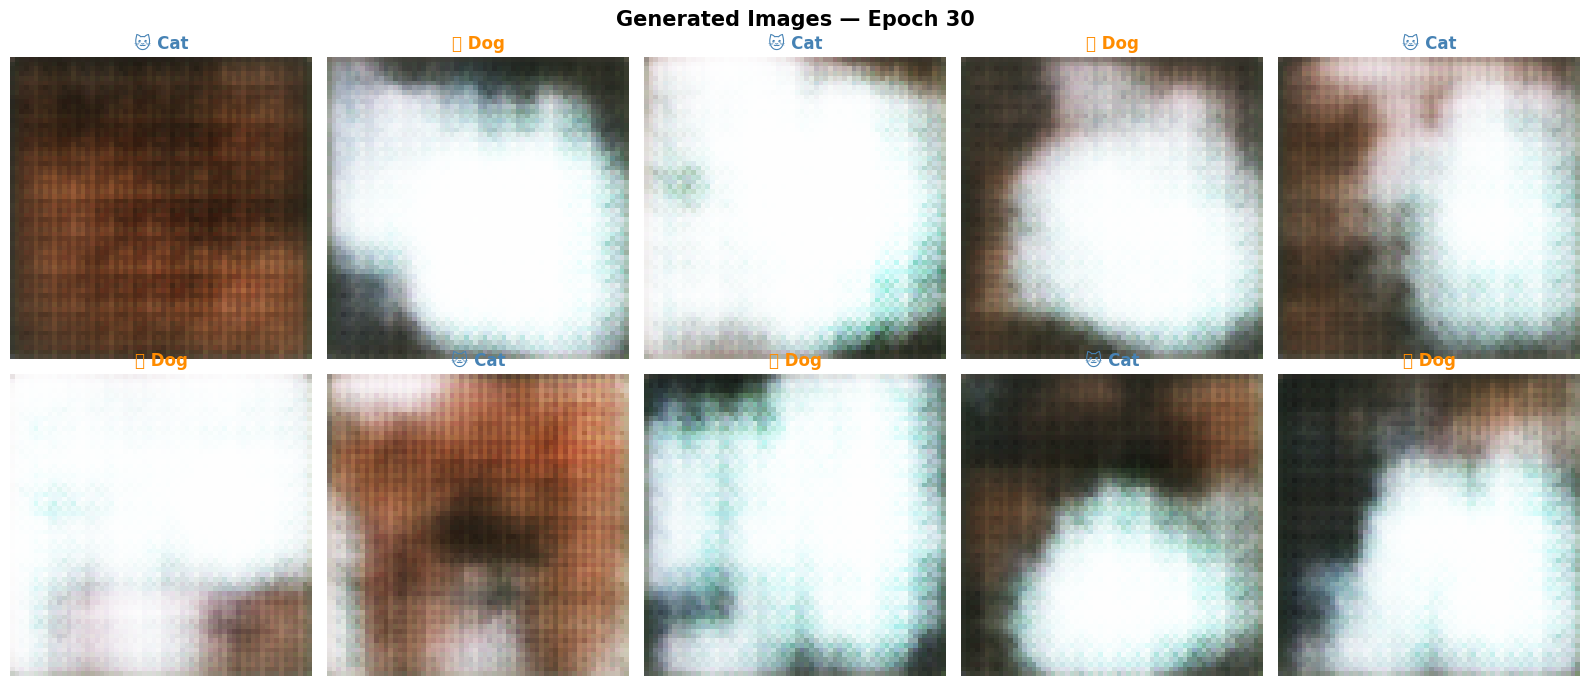

Epoch [31/100]  │  Gen Loss: 0.2151  │  Disc Loss: 0.5997
Epoch [32/100]  │  Gen Loss: 0.1727  │  Disc Loss: 0.5287
Epoch [32/100]  │  Gen Loss: 0.1727  │  Disc Loss: 0.5287
Epoch [33/100]  │  Gen Loss: 0.0784  │  Disc Loss: 0.4349
Epoch [33/100]  │  Gen Loss: 0.0784  │  Disc Loss: 0.4349
Epoch [34/100]  │  Gen Loss: 0.0428  │  Disc Loss: 0.3910
Epoch [34/100]  │  Gen Loss: 0.0428  │  Disc Loss: 0.3910
Epoch [35/100]  │  Gen Loss: 0.0314  │  Disc Loss: 0.3709
Epoch [35/100]  │  Gen Loss: 0.0314  │  Disc Loss: 0.3709


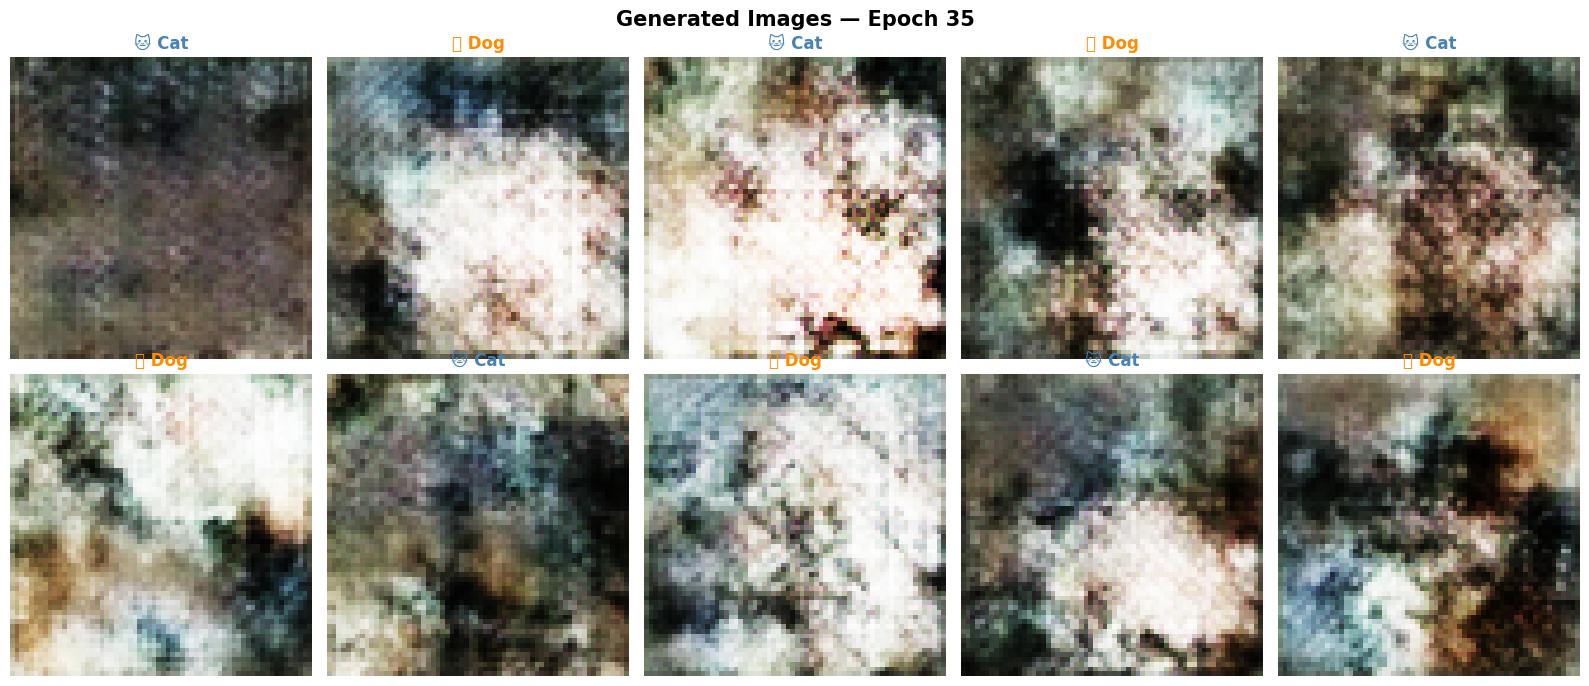

Epoch [36/100]  │  Gen Loss: 0.0172  │  Disc Loss: 0.3468
Epoch [37/100]  │  Gen Loss: 0.0346  │  Disc Loss: 0.3696
Epoch [37/100]  │  Gen Loss: 0.0346  │  Disc Loss: 0.3696
Epoch [38/100]  │  Gen Loss: 0.0163  │  Disc Loss: 0.3415
Epoch [38/100]  │  Gen Loss: 0.0163  │  Disc Loss: 0.3415
Epoch [39/100]  │  Gen Loss: 0.0105  │  Disc Loss: 0.3363
Epoch [39/100]  │  Gen Loss: 0.0105  │  Disc Loss: 0.3363
Epoch [40/100]  │  Gen Loss: 0.2110  │  Disc Loss: 0.5189
Epoch [40/100]  │  Gen Loss: 0.2110  │  Disc Loss: 0.5189


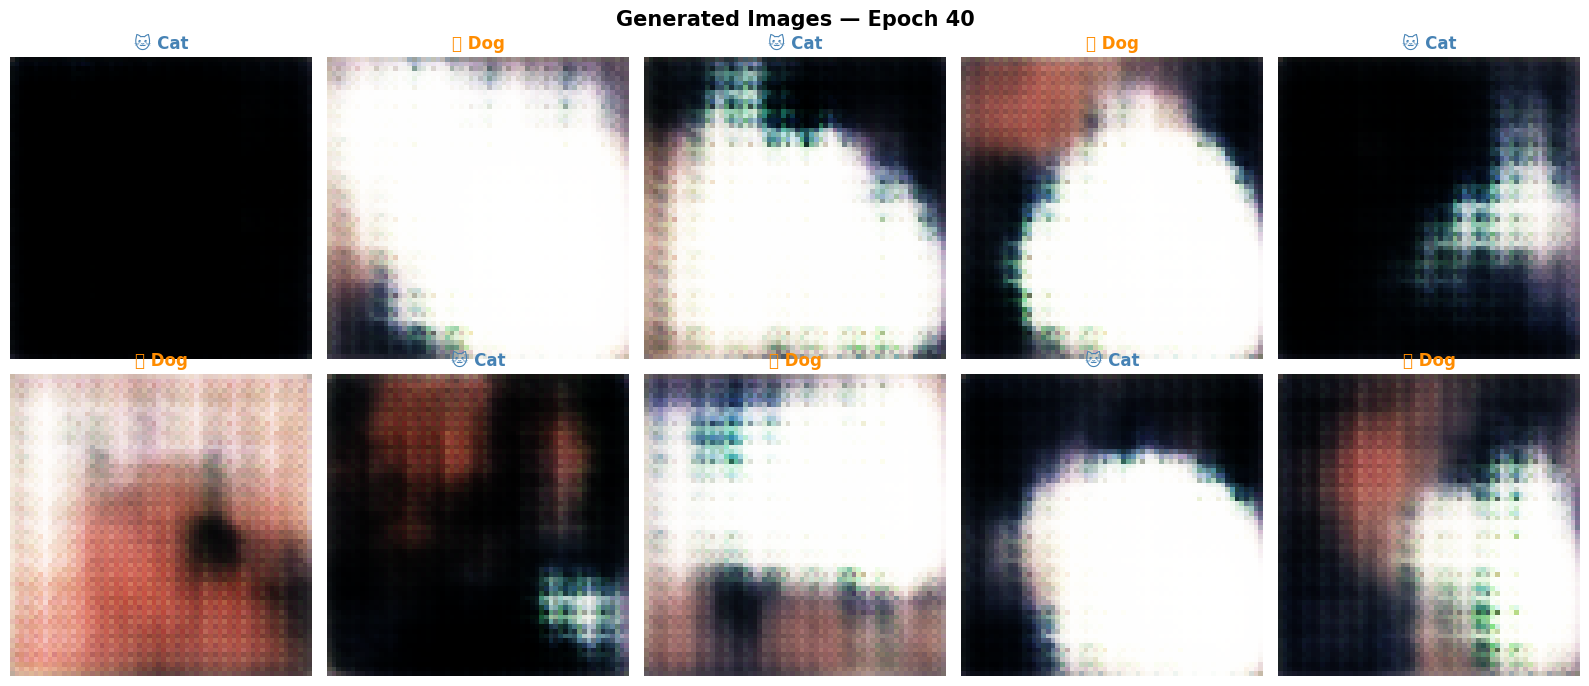

Epoch [41/100]  │  Gen Loss: 0.2834  │  Disc Loss: 0.6272
Epoch [42/100]  │  Gen Loss: 0.1132  │  Disc Loss: 0.4779
Epoch [42/100]  │  Gen Loss: 0.1132  │  Disc Loss: 0.4779
Epoch [43/100]  │  Gen Loss: 0.0480  │  Disc Loss: 0.3939
Epoch [43/100]  │  Gen Loss: 0.0480  │  Disc Loss: 0.3939
Epoch [44/100]  │  Gen Loss: 0.0215  │  Disc Loss: 0.3532
Epoch [44/100]  │  Gen Loss: 0.0215  │  Disc Loss: 0.3532
Epoch [45/100]  │  Gen Loss: 0.0144  │  Disc Loss: 0.3461
Epoch [45/100]  │  Gen Loss: 0.0144  │  Disc Loss: 0.3461


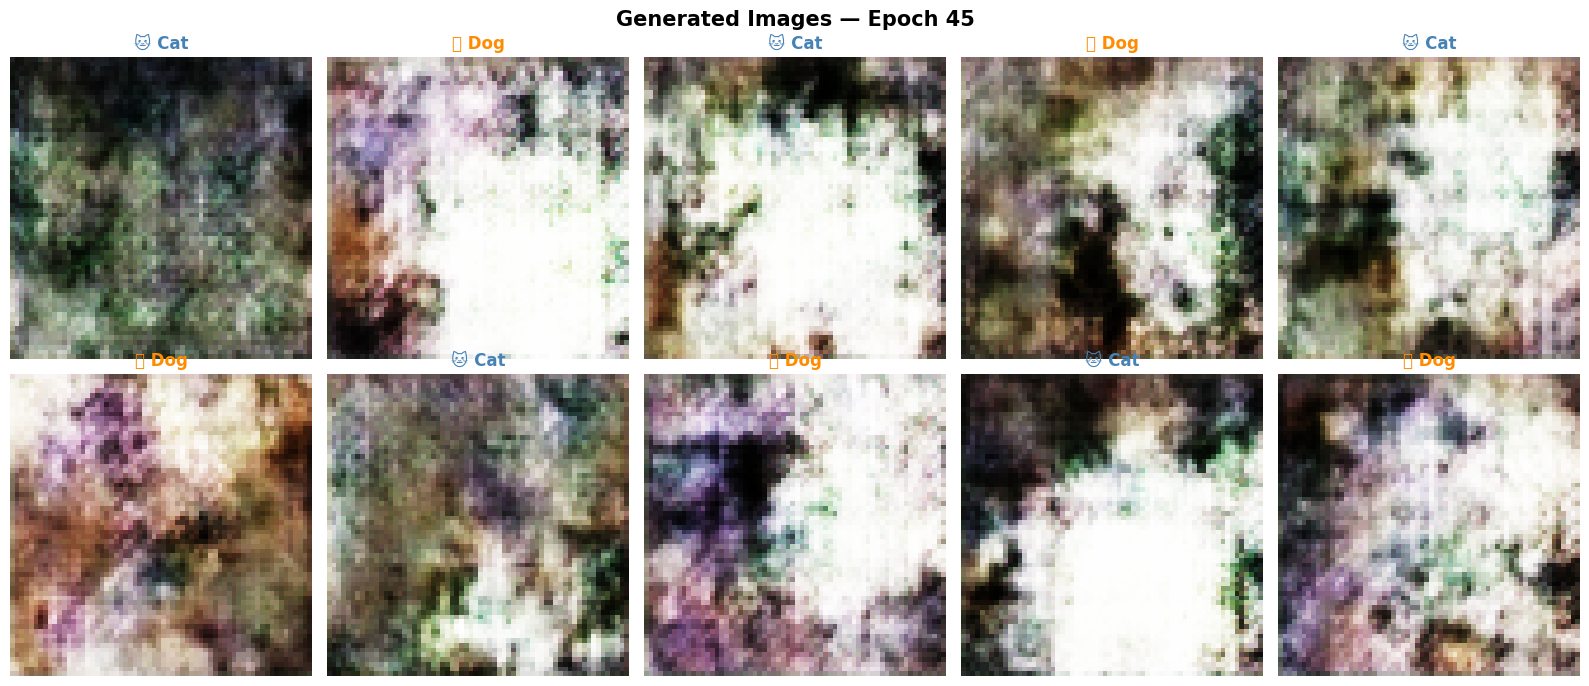

Epoch [46/100]  │  Gen Loss: 0.0298  │  Disc Loss: 0.3723
Epoch [47/100]  │  Gen Loss: 0.0193  │  Disc Loss: 0.3489
Epoch [47/100]  │  Gen Loss: 0.0193  │  Disc Loss: 0.3489
Epoch [48/100]  │  Gen Loss: 0.0085  │  Disc Loss: 0.3351
Epoch [48/100]  │  Gen Loss: 0.0085  │  Disc Loss: 0.3351
Epoch [49/100]  │  Gen Loss: 0.0058  │  Disc Loss: 0.3326
Epoch [49/100]  │  Gen Loss: 0.0058  │  Disc Loss: 0.3326
Epoch [50/100]  │  Gen Loss: 0.0043  │  Disc Loss: 0.3310
Epoch [50/100]  │  Gen Loss: 0.0043  │  Disc Loss: 0.3310


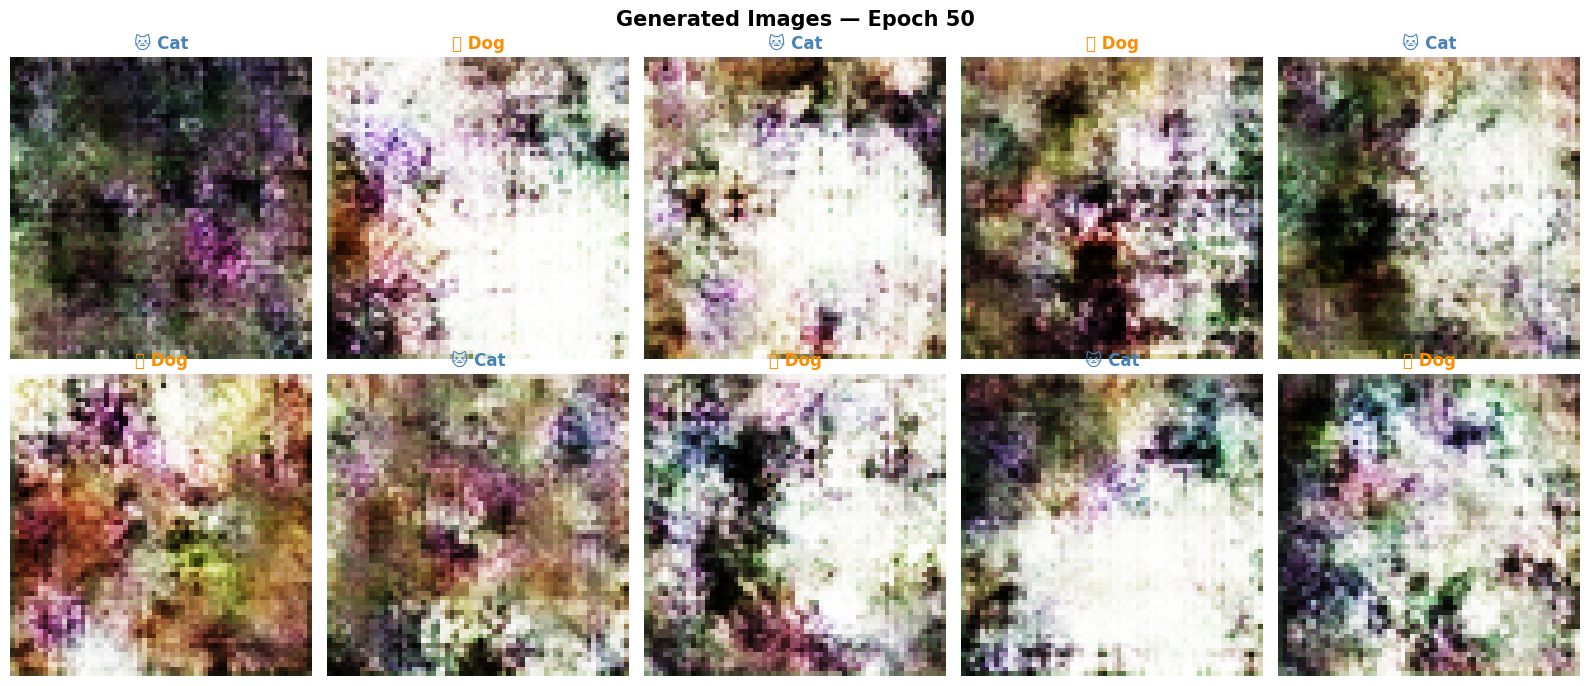

Epoch [51/100]  │  Gen Loss: 0.0032  │  Disc Loss: 0.3304
Epoch [52/100]  │  Gen Loss: 0.0848  │  Disc Loss: 0.4230
Epoch [52/100]  │  Gen Loss: 0.0848  │  Disc Loss: 0.4230
Epoch [53/100]  │  Gen Loss: 0.0801  │  Disc Loss: 0.4347
Epoch [53/100]  │  Gen Loss: 0.0801  │  Disc Loss: 0.4347
Epoch [54/100]  │  Gen Loss: 0.0410  │  Disc Loss: 0.3755
Epoch [54/100]  │  Gen Loss: 0.0410  │  Disc Loss: 0.3755
Epoch [55/100]  │  Gen Loss: 0.0136  │  Disc Loss: 0.3425
Epoch [55/100]  │  Gen Loss: 0.0136  │  Disc Loss: 0.3425


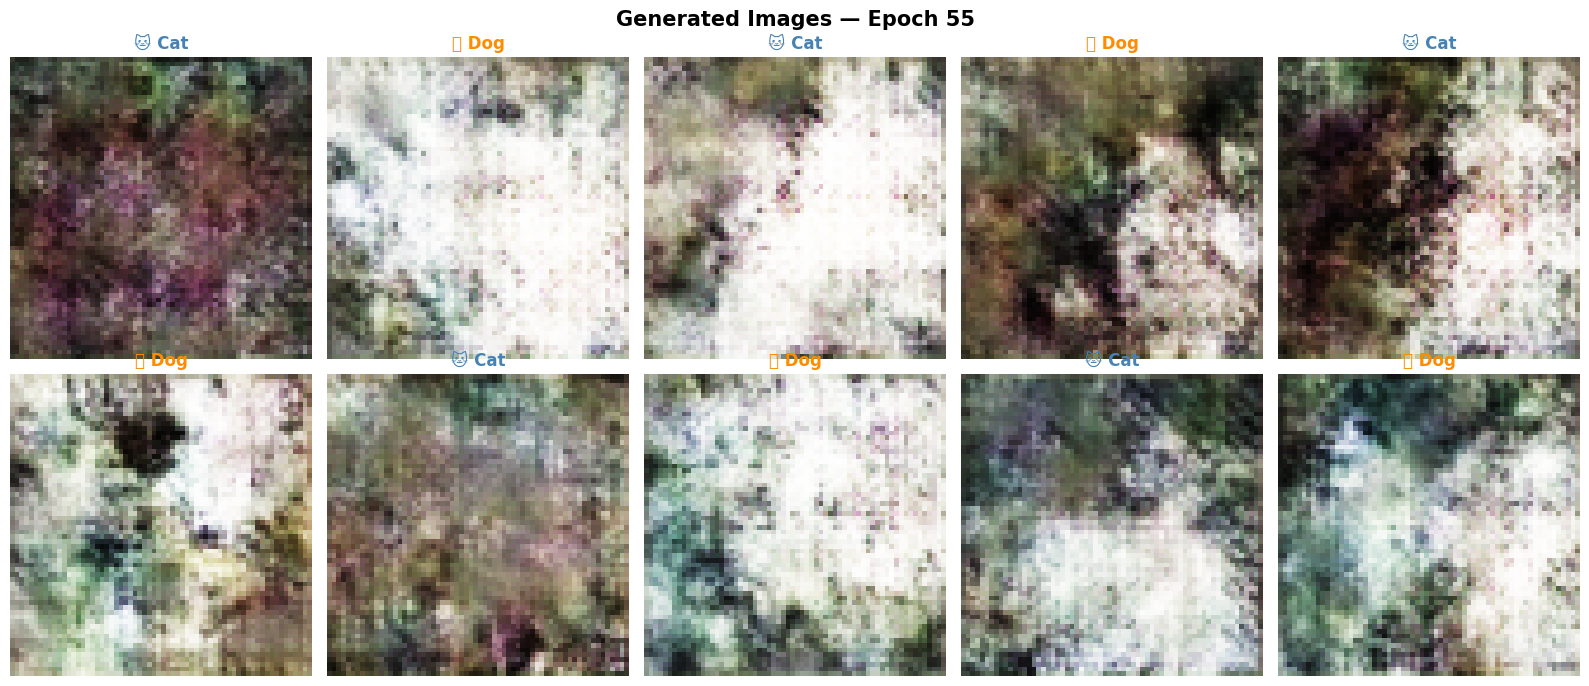

Epoch [56/100]  │  Gen Loss: 0.0104  │  Disc Loss: 0.3370
Epoch [57/100]  │  Gen Loss: 0.0099  │  Disc Loss: 0.3412
Epoch [57/100]  │  Gen Loss: 0.0099  │  Disc Loss: 0.3412
Epoch [58/100]  │  Gen Loss: 0.0059  │  Disc Loss: 0.3333
Epoch [58/100]  │  Gen Loss: 0.0059  │  Disc Loss: 0.3333
Epoch [59/100]  │  Gen Loss: 0.0031  │  Disc Loss: 0.3310
Epoch [59/100]  │  Gen Loss: 0.0031  │  Disc Loss: 0.3310
Epoch [60/100]  │  Gen Loss: 0.0032  │  Disc Loss: 0.3285
Epoch [60/100]  │  Gen Loss: 0.0032  │  Disc Loss: 0.3285


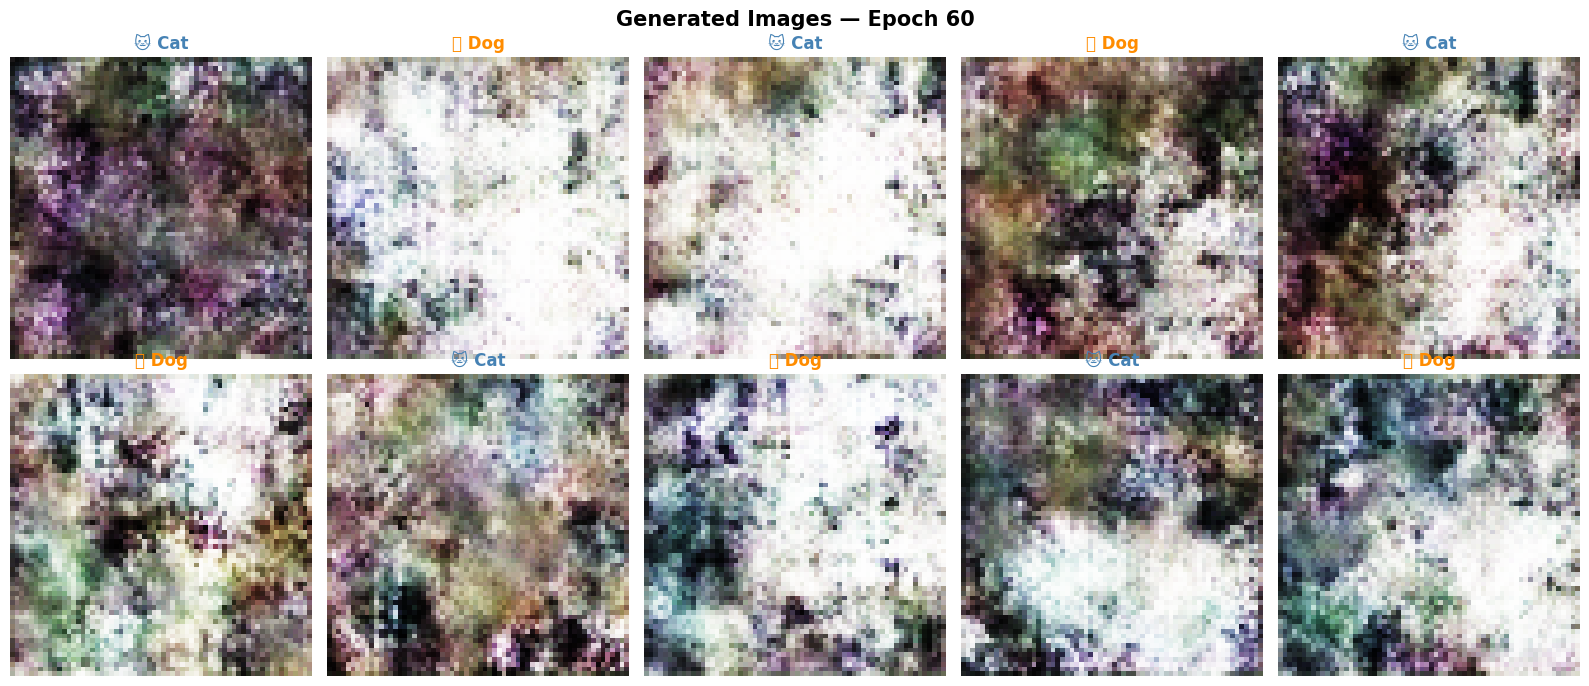

Epoch [61/100]  │  Gen Loss: 0.0044  │  Disc Loss: 0.3314
Epoch [62/100]  │  Gen Loss: 0.3272  │  Disc Loss: 0.6029
Epoch [62/100]  │  Gen Loss: 0.3272  │  Disc Loss: 0.6029
Epoch [63/100]  │  Gen Loss: 0.0822  │  Disc Loss: 0.4420
Epoch [63/100]  │  Gen Loss: 0.0822  │  Disc Loss: 0.4420
Epoch [64/100]  │  Gen Loss: 0.0332  │  Disc Loss: 0.3733
Epoch [64/100]  │  Gen Loss: 0.0332  │  Disc Loss: 0.3733
Epoch [65/100]  │  Gen Loss: 0.0116  │  Disc Loss: 0.3445
Epoch [65/100]  │  Gen Loss: 0.0116  │  Disc Loss: 0.3445


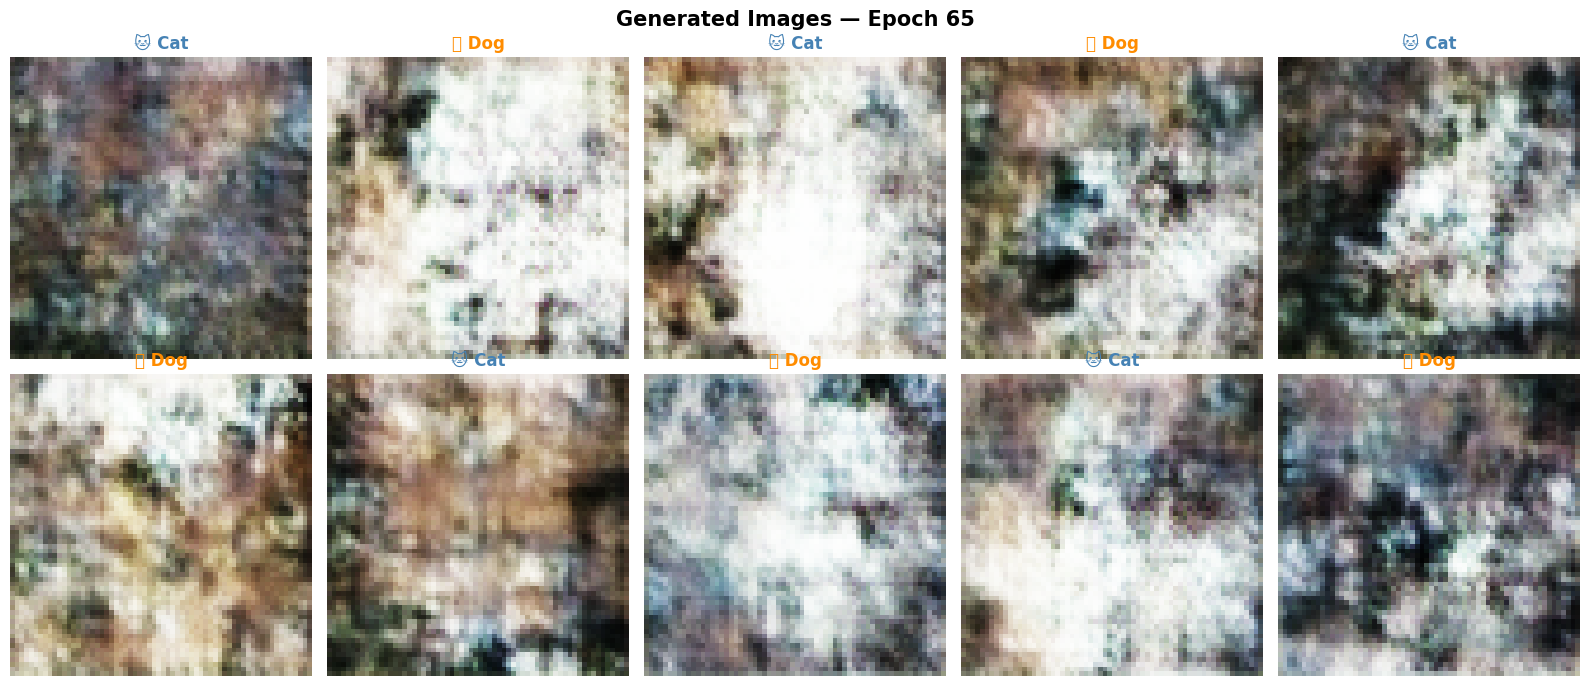

Epoch [66/100]  │  Gen Loss: 0.0300  │  Disc Loss: 0.3689
Epoch [67/100]  │  Gen Loss: 0.0093  │  Disc Loss: 0.3403
Epoch [67/100]  │  Gen Loss: 0.0093  │  Disc Loss: 0.3403
Epoch [68/100]  │  Gen Loss: 0.0054  │  Disc Loss: 0.3325
Epoch [68/100]  │  Gen Loss: 0.0054  │  Disc Loss: 0.3325
Epoch [69/100]  │  Gen Loss: 0.0056  │  Disc Loss: 0.3343
Epoch [69/100]  │  Gen Loss: 0.0056  │  Disc Loss: 0.3343
Epoch [70/100]  │  Gen Loss: 0.0033  │  Disc Loss: 0.3293
Epoch [70/100]  │  Gen Loss: 0.0033  │  Disc Loss: 0.3293


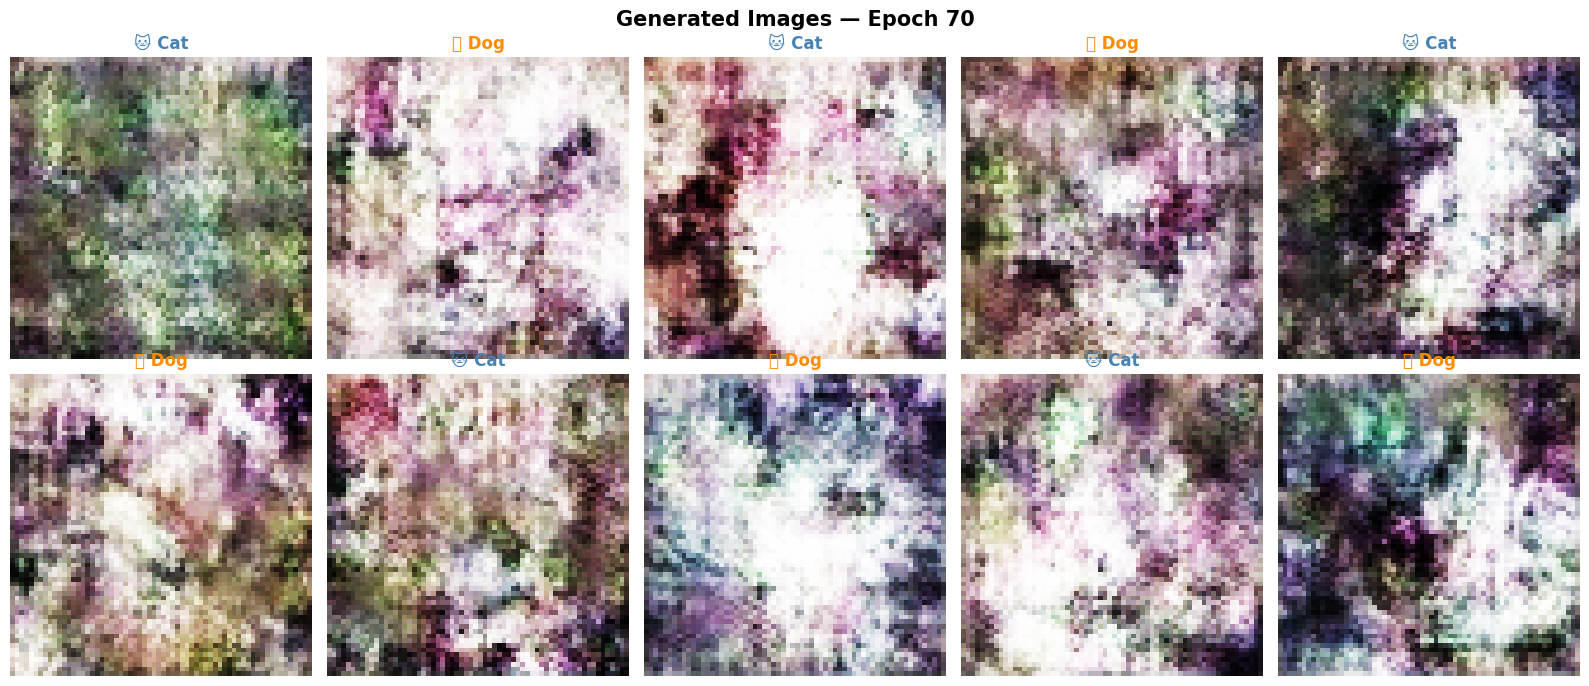

Epoch [71/100]  │  Gen Loss: 0.2247  │  Disc Loss: 0.5499
Epoch [72/100]  │  Gen Loss: 0.0362  │  Disc Loss: 0.3750
Epoch [72/100]  │  Gen Loss: 0.0362  │  Disc Loss: 0.3750
Epoch [73/100]  │  Gen Loss: 0.0085  │  Disc Loss: 0.3400
Epoch [73/100]  │  Gen Loss: 0.0085  │  Disc Loss: 0.3400
Epoch [74/100]  │  Gen Loss: 0.0062  │  Disc Loss: 0.3371
Epoch [74/100]  │  Gen Loss: 0.0062  │  Disc Loss: 0.3371
Epoch [75/100]  │  Gen Loss: 0.0037  │  Disc Loss: 0.3321
Epoch [75/100]  │  Gen Loss: 0.0037  │  Disc Loss: 0.3321


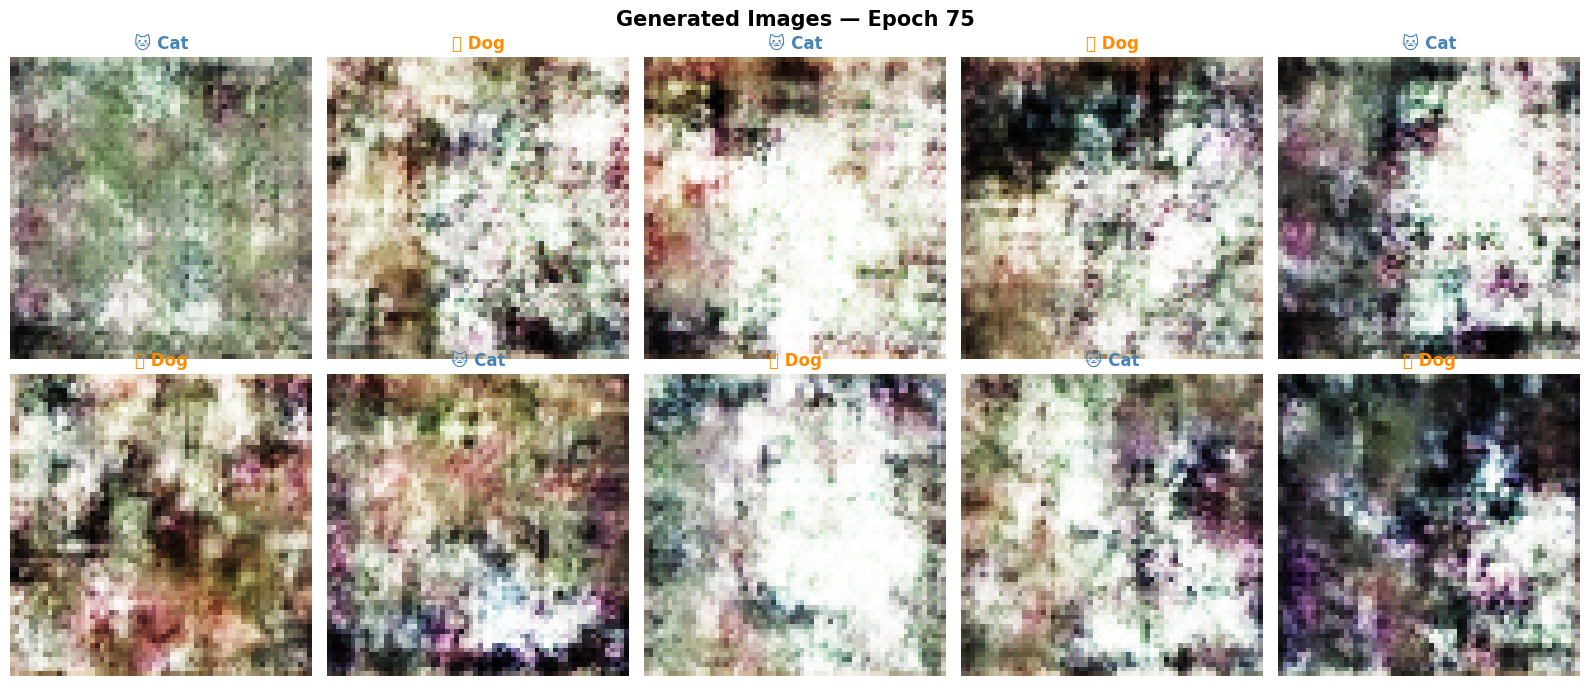

Epoch [76/100]  │  Gen Loss: 0.0031  │  Disc Loss: 0.3314
Epoch [77/100]  │  Gen Loss: 0.0017  │  Disc Loss: 0.3297
Epoch [77/100]  │  Gen Loss: 0.0017  │  Disc Loss: 0.3297
Epoch [78/100]  │  Gen Loss: 0.0482  │  Disc Loss: 0.3629
Epoch [78/100]  │  Gen Loss: 0.0482  │  Disc Loss: 0.3629
Epoch [79/100]  │  Gen Loss: 0.0707  │  Disc Loss: 0.4093
Epoch [79/100]  │  Gen Loss: 0.0707  │  Disc Loss: 0.4093
Epoch [80/100]  │  Gen Loss: 0.0146  │  Disc Loss: 0.3475
Epoch [80/100]  │  Gen Loss: 0.0146  │  Disc Loss: 0.3475


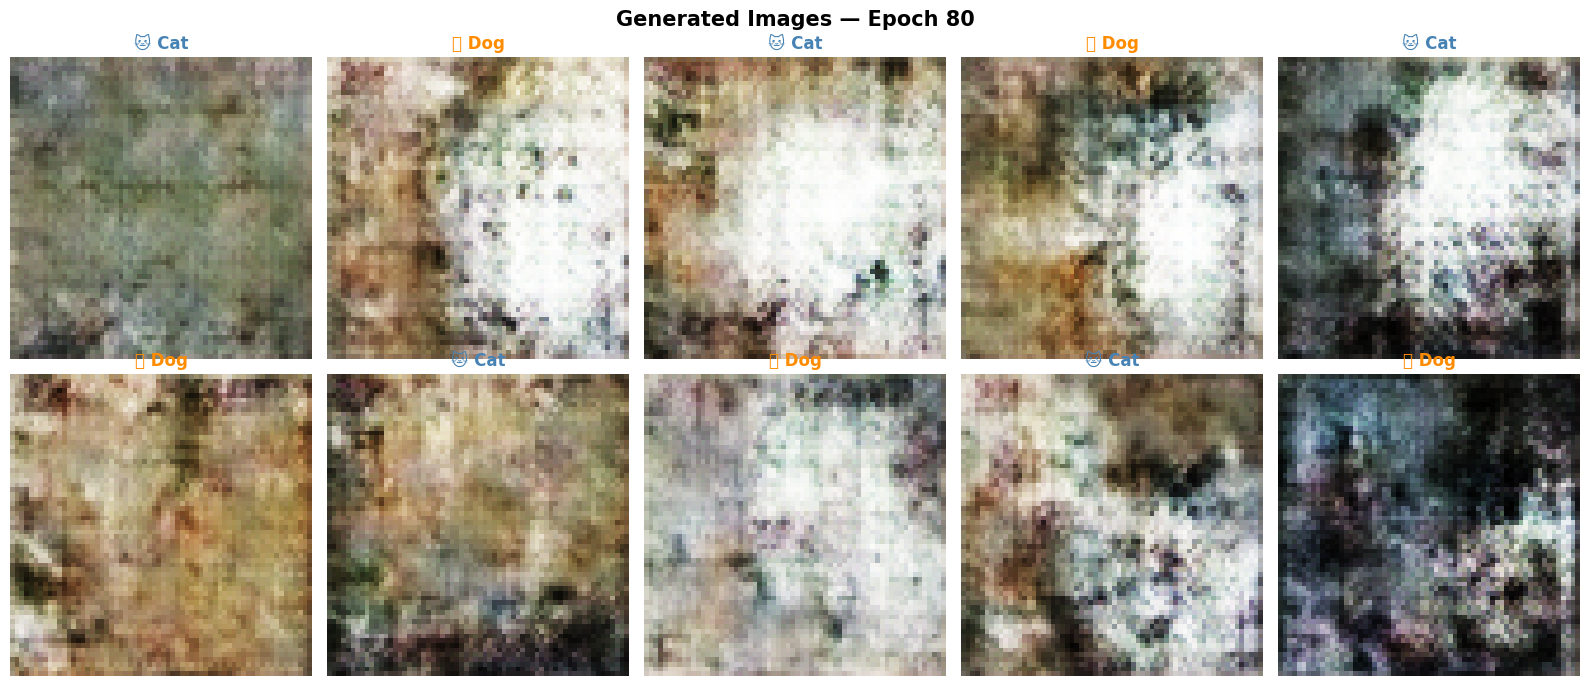

Epoch [81/100]  │  Gen Loss: 0.0048  │  Disc Loss: 0.3331
Epoch [82/100]  │  Gen Loss: 0.0043  │  Disc Loss: 0.3339
Epoch [82/100]  │  Gen Loss: 0.0043  │  Disc Loss: 0.3339
Epoch [83/100]  │  Gen Loss: 0.0022  │  Disc Loss: 0.3286
Epoch [83/100]  │  Gen Loss: 0.0022  │  Disc Loss: 0.3286
Epoch [84/100]  │  Gen Loss: 0.0031  │  Disc Loss: 0.3309
Epoch [84/100]  │  Gen Loss: 0.0031  │  Disc Loss: 0.3309
Epoch [85/100]  │  Gen Loss: 0.0014  │  Disc Loss: 0.3281
Epoch [85/100]  │  Gen Loss: 0.0014  │  Disc Loss: 0.3281


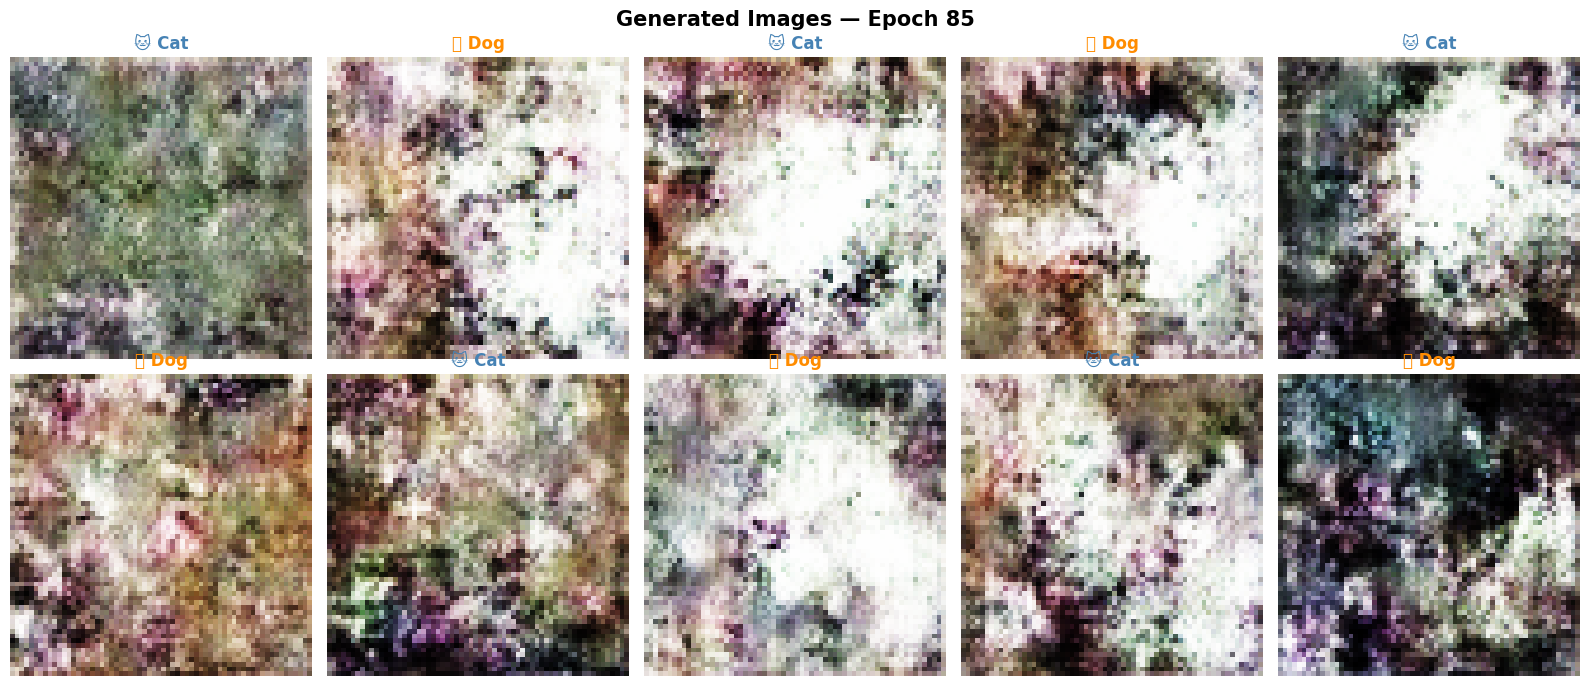

Epoch [86/100]  │  Gen Loss: 0.0016  │  Disc Loss: 0.3284
Epoch [87/100]  │  Gen Loss: 0.1635  │  Disc Loss: 0.4436
Epoch [87/100]  │  Gen Loss: 0.1635  │  Disc Loss: 0.4436
Epoch [88/100]  │  Gen Loss: 0.0445  │  Disc Loss: 0.3828
Epoch [88/100]  │  Gen Loss: 0.0445  │  Disc Loss: 0.3828
Epoch [89/100]  │  Gen Loss: 0.0196  │  Disc Loss: 0.3561
Epoch [89/100]  │  Gen Loss: 0.0196  │  Disc Loss: 0.3561
Epoch [90/100]  │  Gen Loss: 0.0043  │  Disc Loss: 0.3315
Epoch [90/100]  │  Gen Loss: 0.0043  │  Disc Loss: 0.3315


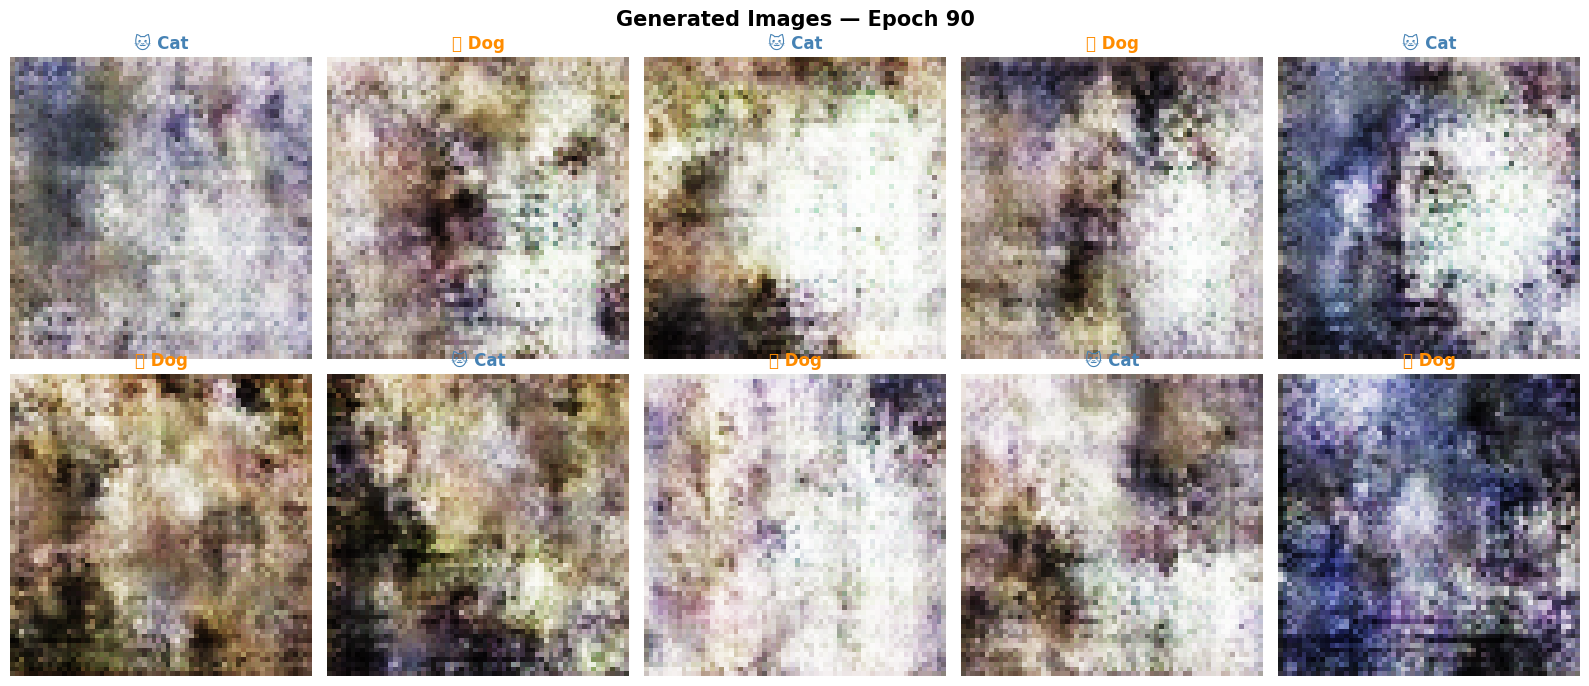

Epoch [91/100]  │  Gen Loss: 0.0038  │  Disc Loss: 0.3309
Epoch [92/100]  │  Gen Loss: 0.0028  │  Disc Loss: 0.3310
Epoch [92/100]  │  Gen Loss: 0.0028  │  Disc Loss: 0.3310
Epoch [93/100]  │  Gen Loss: 0.0023  │  Disc Loss: 0.3308
Epoch [93/100]  │  Gen Loss: 0.0023  │  Disc Loss: 0.3308
Epoch [94/100]  │  Gen Loss: 0.0016  │  Disc Loss: 0.3292
Epoch [94/100]  │  Gen Loss: 0.0016  │  Disc Loss: 0.3292
Epoch [95/100]  │  Gen Loss: 0.0019  │  Disc Loss: 0.3288
Epoch [95/100]  │  Gen Loss: 0.0019  │  Disc Loss: 0.3288


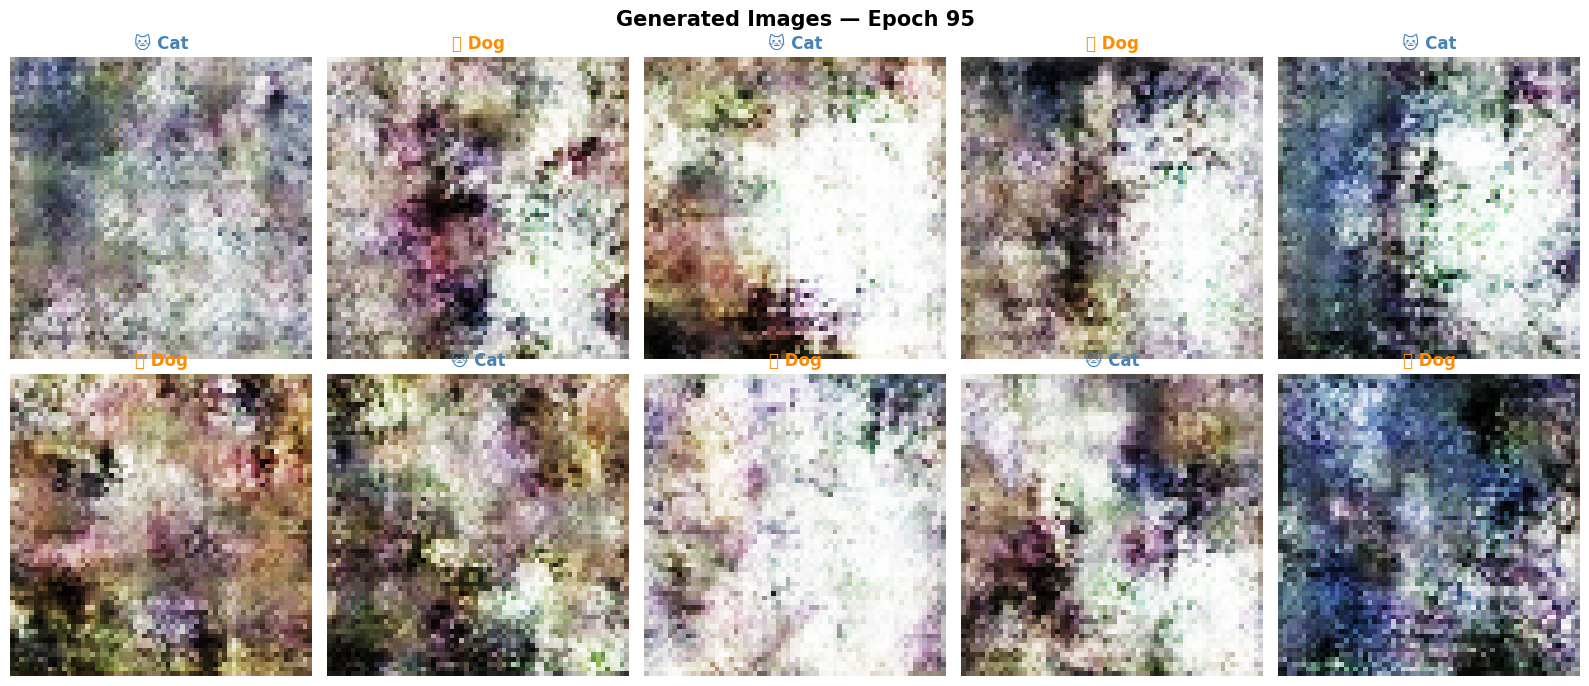

Epoch [96/100]  │  Gen Loss: 0.3126  │  Disc Loss: 0.5589
Epoch [97/100]  │  Gen Loss: 0.1127  │  Disc Loss: 0.4534
Epoch [97/100]  │  Gen Loss: 0.1127  │  Disc Loss: 0.4534
Epoch [98/100]  │  Gen Loss: 0.0247  │  Disc Loss: 0.3652
Epoch [98/100]  │  Gen Loss: 0.0247  │  Disc Loss: 0.3652
Epoch [99/100]  │  Gen Loss: 0.0081  │  Disc Loss: 0.3391
Epoch [99/100]  │  Gen Loss: 0.0081  │  Disc Loss: 0.3391
Epoch [100/100]  │  Gen Loss: 0.0248  │  Disc Loss: 0.3621
Epoch [100/100]  │  Gen Loss: 0.0248  │  Disc Loss: 0.3621


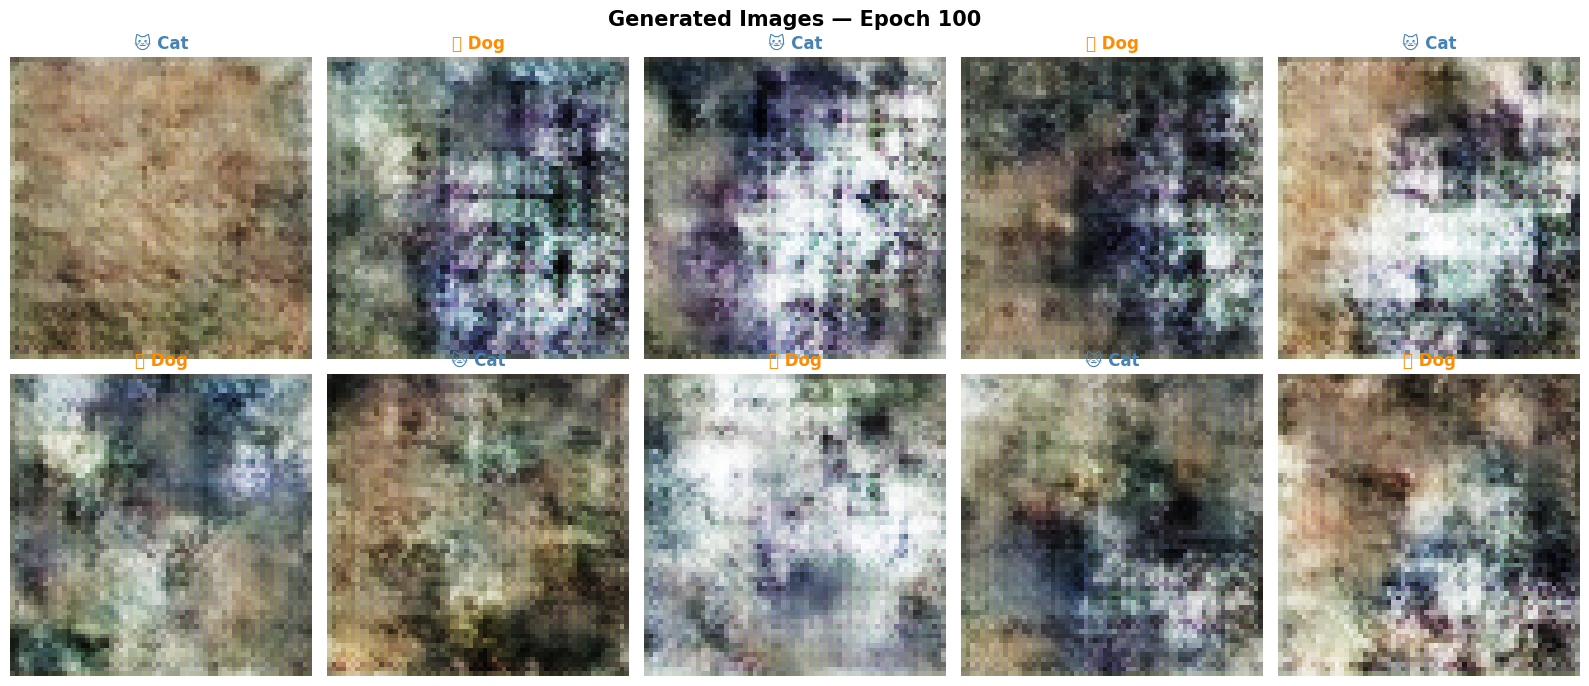


✅ Training complete!


In [13]:
gen_loss_history  = []
disc_loss_history = []

# ── Metrics instantiated ONCE — reset each epoch (no new allocations) ─────────
g_metric = tf.keras.metrics.Mean(name="g_loss")
d_metric = tf.keras.metrics.Mean(name="d_loss")

print("=" * 64)
print("          cGAN Training — Apple Mac Mini M4 · Metal")
print(f"  Epochs={EPOCHS}  Batch={BATCH_SIZE}  Noise={NOISE_DIM}  LR={LR}")
print(f"  ClipNorm={CLIP_NORM}  LabelSmooth={LABEL_SMOOTH}")
print("=" * 64)

for epoch in range(1, EPOCHS + 1):
    g_metric.reset_state()
    d_metric.reset_state()

    for batch_images, batch_labels in train_dataset:
        g_loss, d_loss = train_step(batch_images, batch_labels)
        g_metric.update_state(g_loss)
        d_metric.update_state(d_loss)

    avg_g = float(g_metric.result())
    avg_d = float(d_metric.result())
    gen_loss_history.append(avg_g)
    disc_loss_history.append(avg_d)

    print(f"Epoch [{epoch:>2}/{EPOCHS}]  │  Gen Loss: {avg_g:.4f}  │  Disc Loss: {avg_d:.4f}")

    if epoch % 5 == 0 or epoch == EPOCHS:
        generate_and_show(epoch=epoch, save=True)

print("\n✅ Training complete!")

### 4.4 — Training Loss Curves

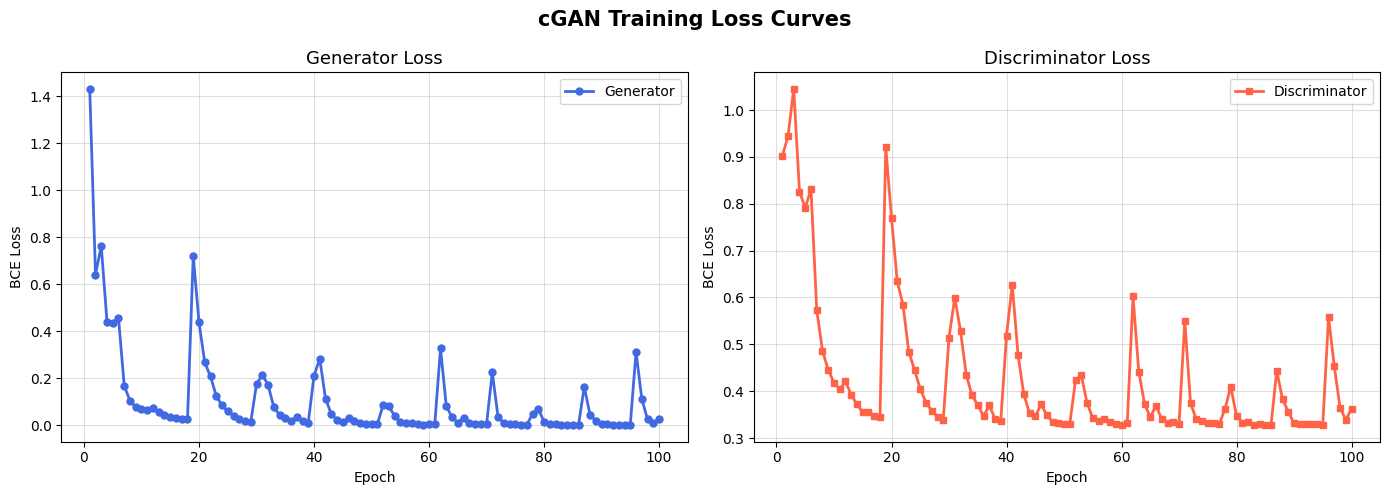

Final Generator Loss     : 0.0248
Final Discriminator Loss : 0.3621


In [14]:
assert len(gen_loss_history) > 0, "Run the training loop cell first!"

epoch_axis = range(1, len(gen_loss_history) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("cGAN Training Loss Curves", fontsize=15, fontweight="bold")

axes[0].plot(epoch_axis, gen_loss_history,
             color="royalblue", linewidth=2, marker="o", markersize=5, label="Generator")
axes[0].set_title("Generator Loss",  fontsize=13)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE Loss")
axes[0].grid(True, alpha=0.4); axes[0].legend()

axes[1].plot(epoch_axis, disc_loss_history,
             color="tomato", linewidth=2, marker="s", markersize=5, label="Discriminator")
axes[1].set_title("Discriminator Loss", fontsize=13)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("BCE Loss")
axes[1].grid(True, alpha=0.4); axes[1].legend()

plt.tight_layout()
plt.savefig("cgan_outputs/loss_curves.png", dpi=100, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Final Generator Loss     : {gen_loss_history[-1]:.4f}")
print(f"Final Discriminator Loss : {disc_loss_history[-1]:.4f}")

---
## Part 5 — Evaluation & Visualization

### 5.1 — Random Conditioned Generation (4×4 grid)

/var/folders/xb/h9lj1q7n4094ljx17mfmchq80000gn/T/ipykernel_4606/1689945611.py:28: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/xb/h9lj1q7n4094ljx17mfmchq80000gn/T/ipykernel_4606/1689945611.py:29: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  plt.savefig("cgan_outputs/final_generated_images.png", dpi=120, bbox_inches="tight")


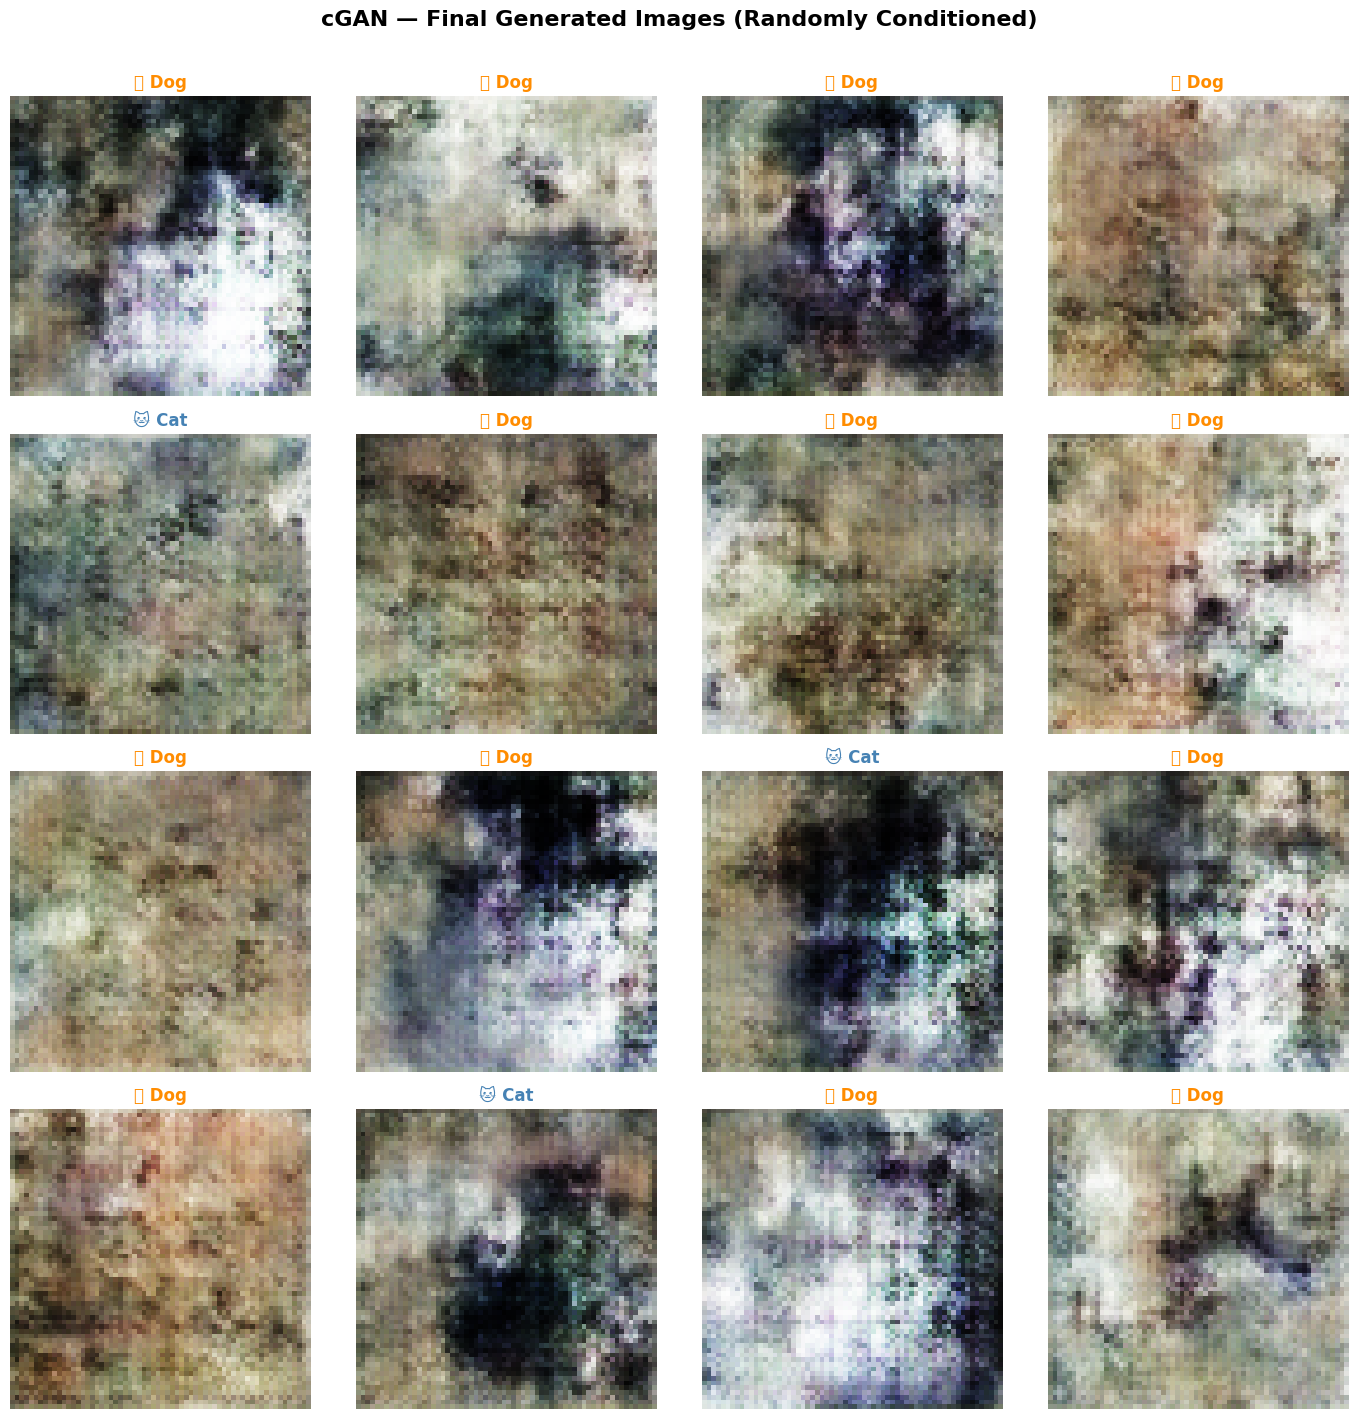

✅ Saved → cgan_outputs/final_generated_images.png


In [15]:
rng         = np.random.default_rng(seed=99)
NUM_EVAL    = 16
eval_noise  = tf.random.stateless_normal([NUM_EVAL, NOISE_DIM], seed=(99, 1))
eval_labels = tf.constant(
    [[int(rng.integers(0, NUM_CLASSES))] for _ in range(NUM_EVAL)],
    dtype=tf.int32
)

eval_images = denormalize(
    generator([eval_noise, eval_labels], training=False)
)

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.suptitle(
    "cGAN — Final Generated Images (Randomly Conditioned)",
    fontsize=16, fontweight="bold", y=1.01
)

for i, ax in enumerate(axes.flatten()):
    ax.imshow(eval_images[i])
    name  = LABEL_NAMES[int(eval_labels[i][0].numpy())]
    emoji = "🐱" if name == "cat" else "🐶"
    color = "steelblue" if name == "cat" else "darkorange"
    ax.set_title(f"{emoji} {name.capitalize()}", fontsize=12,
                 color=color, fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.savefig("cgan_outputs/final_generated_images.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)
print("✅ Saved → cgan_outputs/final_generated_images.png")

### 5.2 — Pure Class-Conditioned Grid
Fixed label per row, varied noise — directly demonstrates conditioning.

/var/folders/xb/h9lj1q7n4094ljx17mfmchq80000gn/T/ipykernel_4606/408753131.py:27: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/xb/h9lj1q7n4094ljx17mfmchq80000gn/T/ipykernel_4606/408753131.py:28: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  plt.savefig("cgan_outputs/class_conditioned_grid.png", dpi=120, bbox_inches="tight")


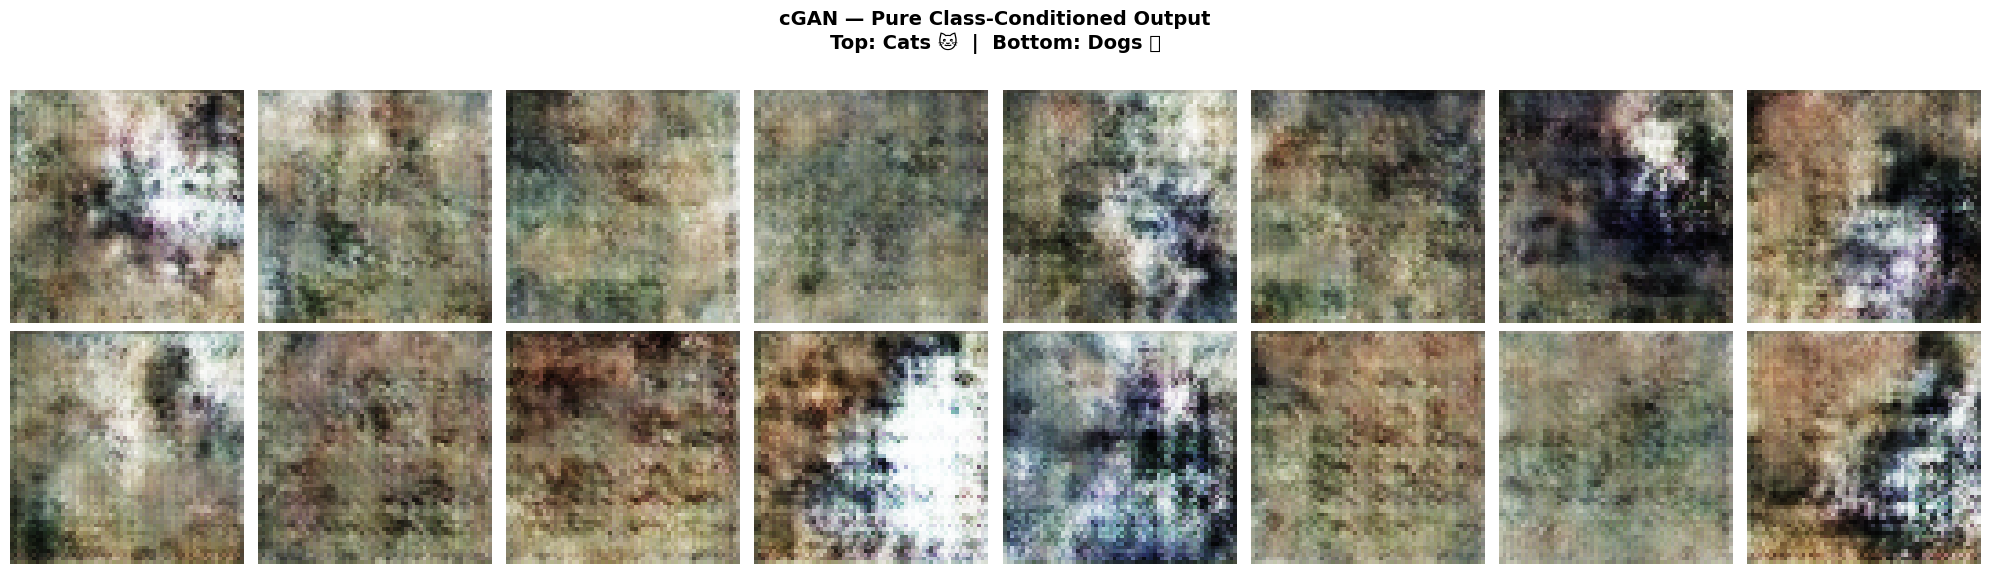

✅ Saved → cgan_outputs/class_conditioned_grid.png


In [16]:
fig, axes = plt.subplots(2, 8, figsize=(20, 6))
fig.suptitle(
    "cGAN — Pure Class-Conditioned Output\nTop: Cats 🐱  |  Bottom: Dogs 🐶",
    fontsize=14, fontweight="bold"
)

for class_id in range(NUM_CLASSES):
    class_name  = LABEL_NAMES[class_id]
    noise_batch = tf.random.stateless_normal([8, NOISE_DIM], seed=(class_id, 7))
    label_batch = tf.constant([[class_id]] * 8, dtype=tf.int32)

    gen_batch = denormalize(
        generator([noise_batch, label_batch], training=False)
    )

    color = "steelblue" if class_name == "cat" else "darkorange"
    emoji = "🐱" if class_name == "cat" else "🐶"

    for j in range(8):
        ax = axes[class_id][j]
        ax.imshow(gen_batch[j])
        ax.axis("off")
        if j == 0:
            ax.set_ylabel(f"{emoji} {class_name.capitalize()}",
                          fontsize=13, fontweight="bold", color=color)

plt.tight_layout()
plt.savefig("cgan_outputs/class_conditioned_grid.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)
print("✅ Saved → cgan_outputs/class_conditioned_grid.png")

### 5.3 — Same Noise, Flipped Label
Holds noise constant, switches only the class label — isolates the conditioning signal's contribution.

/var/folders/xb/h9lj1q7n4094ljx17mfmchq80000gn/T/ipykernel_4606/1509930858.py:24: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/xb/h9lj1q7n4094ljx17mfmchq80000gn/T/ipykernel_4606/1509930858.py:25: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  plt.savefig("cgan_outputs/label_flip.png", dpi=120, bbox_inches="tight")


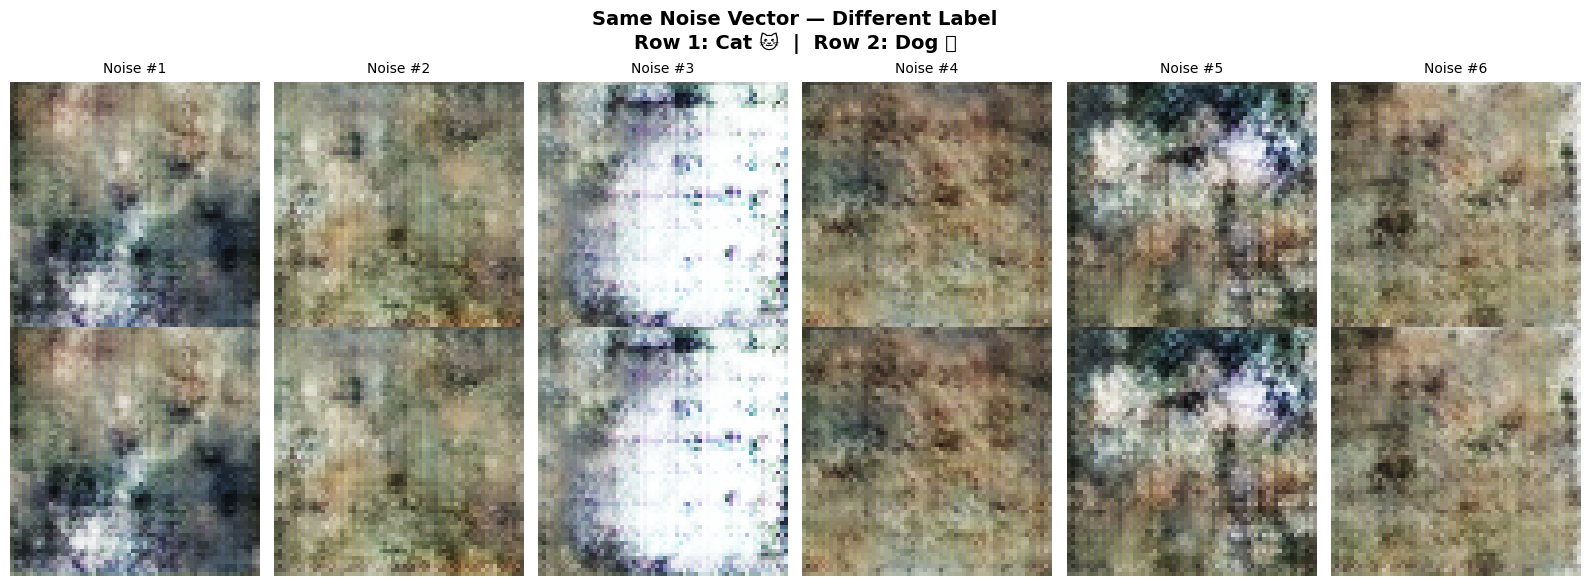

✅ Saved → cgan_outputs/label_flip.png


In [17]:
N_PAIRS      = 6
interp_noise = tf.random.stateless_normal([N_PAIRS, NOISE_DIM], seed=(123, 0))

cat_labels = tf.constant([[0]] * N_PAIRS, dtype=tf.int32)
dog_labels = tf.constant([[1]] * N_PAIRS, dtype=tf.int32)

cats = denormalize(generator([interp_noise, cat_labels], training=False))
dogs = denormalize(generator([interp_noise, dog_labels], training=False))

fig, axes = plt.subplots(2, N_PAIRS, figsize=(16, 6))
fig.suptitle(
    "Same Noise Vector — Different Label\nRow 1: Cat 🐱  |  Row 2: Dog 🐶",
    fontsize=14, fontweight="bold"
)

for j in range(N_PAIRS):
    axes[0][j].imshow(cats[j]); axes[0][j].axis("off")
    axes[1][j].imshow(dogs[j]); axes[1][j].axis("off")
    axes[0][j].set_title(f"Noise #{j + 1}", fontsize=10)

axes[0][0].set_ylabel("🐱 Cat", fontsize=12, fontweight="bold", color="steelblue")
axes[1][0].set_ylabel("🐶 Dog", fontsize=12, fontweight="bold", color="darkorange")

plt.tight_layout()
plt.savefig("cgan_outputs/label_flip.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)
print("✅ Saved → cgan_outputs/label_flip.png")

---
## Summary

In [18]:
print("=" * 62)
print("              cGAN Project Summary")
print("=" * 62)
print(f"  Architecture         : Conditional GAN (cGAN)")
print(f"  Dataset              : cats_vs_dogs  (TensorFlow Datasets)")
print(f"  Classes              : 0=Cat 🐱  |  1=Dog 🐶")
print(f"  Output resolution    : {IMAGE_SIZE} × {IMAGE_SIZE} × 3")
print(f"  Noise dimension      : {NOISE_DIM}")
print(f"  Batch size           : {BATCH_SIZE}")
print(f"  Epochs trained       : {EPOCHS}")
print(f"  Final Gen  Loss      : {gen_loss_history[-1]:.4f}")
print(f"  Final Disc Loss      : {disc_loss_history[-1]:.4f}")
print(f"  Hardware             : Apple Mac Mini M4 · Metal GPU")
print(f"  Saved outputs        : ./cgan_outputs/")
print("=" * 62)
print("\n🎉 cGAN successfully trained to generate class-conditioned")
print("   cat and dog images!")

              cGAN Project Summary
  Architecture         : Conditional GAN (cGAN)
  Dataset              : cats_vs_dogs  (TensorFlow Datasets)
  Classes              : 0=Cat 🐱  |  1=Dog 🐶
  Output resolution    : 64 × 64 × 3
  Noise dimension      : 128
  Batch size           : 128
  Epochs trained       : 100
  Final Gen  Loss      : 0.0248
  Final Disc Loss      : 0.3621
  Hardware             : Apple Mac Mini M4 · Metal GPU
  Saved outputs        : ./cgan_outputs/

🎉 cGAN successfully trained to generate class-conditioned
   cat and dog images!
